# Explainable Multi-Entity Fraud Intelligence Framework

## JP Morgan Data Analytics Internship Project



### Objective
The objective of this project is to analyze banking transaction, customer, and merchant datasets in order to identify fraud patterns, generate explainable risk intelligence, and prioritize high-risk alerts efficiently.

This project focuses on understanding fraud behavior from multiple perspectives including transaction activity, customer behavior, and merchant risk ecosystems.

Fraud operations teams face increasing alert volumes, synthetic identity risks, and constrained investigation capacity. 

This project builds an explainable fraud-alert prioritization framework designed to:
- identify suspicious transactions,
- prioritize investigator queues,
- improve operational efficiency,
- and provide explainable risk indicators for fraud analysts.

The solution combines:
- fraud risk modeling,
- behavioral analytics,
- operational dashboards,
- and investigator triage workflows.

# Importing Python Libraries

This step imports the required Python libraries used throughout the project.

- pandas → data manipulation and analysis
- numpy → numerical operations
- matplotlib → data visualization
- seaborn → statistical visualizations

These libraries form the foundation of data analytics workflows in Python.

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Loading Datasets

This step loads the three core datasets used in the project:

1. Transactions Dataset
   - Contains transaction-level fraud activity and behavioral signals.

2. Customers Dataset
   - Contains customer-level demographic and behavioral information.

3. Merchants Dataset
   - Contains merchant-level transaction and risk information.

Loading all datasets enables multi-entity fraud analysis instead of isolated transaction-level analysis.

In [2]:
transactions = pd.read_csv('../../B_Dataset/raw/transactions.csv')

customers = pd.read_csv('../../B_Dataset/raw/customers.csv')

merchants = pd.read_csv('../../B_Dataset/raw/merchants.csv')

## Project Assumptions and Scope

This analysis uses synthetic transaction, customer, and merchant data to simulate a fraud-alert prioritisation workflow for investigator triage.

The primary unit of analysis is one transaction. Each row in the final enriched dataset represents one transaction enriched with customer and merchant attributes.

The target variable is `fraud_label`.

This project should be interpreted as a prototype fraud operations framework rather than a production fraud control system. Model scores and risk tiers are designed to support analyst review and prioritisation, not automatic customer blocking.

Key assumptions:

- The datasets are synthetic and used for analytical simulation.
- Fraud investigation outcomes are simplified into a binary `fraud_label`.
- Customer risk bands and synthetic identity indicators are simplified representations.
- Real-time latency, payment authorisation rules, and live case management systems are outside the project scope.
- Model outputs are treated as decision-support signals for investigators.
- Human review remains required for high-risk fraud decisions.

## Data Lineage and Audit Checks

To make the analysis reproducible and audit-ready, the raw datasets are validated before modelling and dashboard preparation.

This section confirms:

- Which raw datasets are used
- The join keys used to enrich transaction-level data
- Row counts before and after joins
- Duplicate checks
- Missing target checks
- Fraud rate consistency
- Final modelling grain

The modelling grain is:

**One row = one transaction**

The target variable is:

**`fraud_label`**

The operational alert indicator is:

**`alert_generated`**, used for operational monitoring and dashboard analysis where relevant, but excluded from model training to reduce leakage risk.

In [3]:
# Data lineage and audit checks

lineage_summary = pd.DataFrame({
    "Dataset": ["transactions.csv", "customers.csv", "merchants.csv"],
    "Original Rows": [len(transactions), len(customers), len(merchants)],
    "Join Key": [
        "transaction_id / customer_id / merchant_id",
        "customer_id",
        "merchant_id"
    ],
    "Primary Use": [
        "Transaction-level modelling and fraud target",
        "Customer enrichment: segment, KYC and synthetic identity attributes",
        "Merchant enrichment: merchant category and merchant risk attributes"
    ],
    "Duplicate Check": [
        transactions["transaction_id"].duplicated().sum(),
        customers["customer_id"].duplicated().sum(),
        merchants["merchant_id"].duplicated().sum()
    ],
    "Missing Target Check": [
        transactions["fraud_label"].isna().sum(),
        "Not applicable",
        "Not applicable"
    ]
})

lineage_summary

,Dataset,Original Rows,Join Key,Primary Use,Duplicate Check,Missing Target Check
0,transactions.csv,5000,transaction_id / customer_id / merchant_id,Transaction-level modelling and fraud target,0,0
1,customers.csv,5000,customer_id,"Customer enrichment: segment, KYC and syntheti...",0,Not applicable
2,merchants.csv,5000,merchant_id,Merchant enrichment: merchant category and mer...,0,Not applicable


In [4]:
# Core sanity checks for transaction-level modelling

sanity_checks = {
    "Transaction rows": len(transactions),
    "Unique transaction IDs": transactions["transaction_id"].nunique(),
    "Duplicate transaction IDs": transactions["transaction_id"].duplicated().sum(),
    "Missing fraud_label values": transactions["fraud_label"].isna().sum(),
    "Fraud cases": int(transactions["fraud_label"].sum()),
    "Fraud rate (%)": round(transactions["fraud_label"].mean() * 100, 2)
}

sanity_checks

{'Transaction rows': 5000,
 'Unique transaction IDs': 5000,
 'Duplicate transaction IDs': np.int64(0),
 'Missing fraud_label values': np.int64(0),
 'Fraud cases': 201,
 'Fraud rate (%)': np.float64(4.02)}

In [5]:
# Join validation checks before creating the enriched modelling dataset

transactions_before_join = len(transactions)

merged_audit = transactions.merge(
    customers,
    on="customer_id",
    how="left",
    indicator="customer_join_status"
)

merged_audit = merged_audit.merge(
    merchants,
    on="merchant_id",
    how="left",
    indicator="merchant_join_status"
)

join_validation_summary = pd.DataFrame({
    "Check": [
        "Transaction rows before joins",
        "Transaction rows after joins",
        "Rows preserved after enrichment",
        "Unique transaction IDs after joins",
        "Customer records matched",
        "Customer records not matched",
        "Merchant records matched",
        "Merchant records not matched",
        "Fraud rate after joins (%)"
    ],
    "Value": [
        transactions_before_join,
        len(merged_audit),
        len(merged_audit) == transactions_before_join,
        merged_audit["transaction_id"].nunique(),
        (merged_audit["customer_join_status"] == "both").sum(),
        (merged_audit["customer_join_status"] == "left_only").sum(),
        (merged_audit["merchant_join_status"] == "both").sum(),
        (merged_audit["merchant_join_status"] == "left_only").sum(),
        round(merged_audit["fraud_label"].mean() * 100, 2)
    ]
})

join_validation_summary

,Check,Value
0,Transaction rows before joins,5000
1,Transaction rows after joins,5000
2,Rows preserved after enrichment,True
3,Unique transaction IDs after joins,5000
4,Customer records matched,4178
5,Customer records not matched,822
6,Merchant records matched,5000
7,Merchant records not matched,0
8,Fraud rate after joins (%),4.02


### Data Lineage Interpretation

The join validation confirms that all 5,000 transaction rows were preserved after enriching the transaction data with customer and merchant attributes.

No duplicate transaction records were created during the enrichment process, and the fraud rate remained stable at 4.02% after the joins. This confirms that the modelling and dashboard dataset preserves the correct transaction-level grain.

Customer enrichment matched 4,178 transactions, while 822 transactions did not have matching customer records. These unmatched customer attributes are retained as missing values and handled during preprocessing to avoid dropping valid transaction records.

Merchant enrichment matched all 5,000 transactions, confirming full merchant coverage in the enriched dataset.

## Fraud Feature Rationale

Fraud feature engineering should not only create variables for modelling; each feature should have a clear fraud hypothesis and operational use.

The table below explains the key fraud-relevant features used in the analysis, why they matter, the expected risk direction, and how they support investigator triage or dashboard interpretation.

In [6]:
# Fraud feature rationale table

feature_rationale = pd.DataFrame({
    "Feature": [
        "device_risk_score",
        "merchant_risk_score",
        "new_device_flag",
        "is_night_flag",
        "velocity_1h",
        "velocity_24h",
        "geo_distance_km",
        "channel",
        "merchant_category",
        "kyc_risk_band",
        "synthetic_identity_score"
    ],
    "Fraud Rationale": [
        "Higher device risk may indicate suspicious device behaviour or possible account compromise.",
        "Higher merchant risk may indicate merchants with greater exposure to fraudulent activity.",
        "A new or unfamiliar device may indicate account takeover or unauthorised access.",
        "Night-time transactions may occur outside normal customer behaviour patterns.",
        "High short-term transaction velocity may indicate rapid fraud attempts.",
        "High 24-hour transaction velocity may indicate repeated suspicious activity.",
        "Large geographic distance may indicate unusual location behaviour or possible geo anomaly.",
        "Certain channels, such as P2P or Wire, may carry higher fraud exposure.",
        "Some merchant categories may show higher fraud concentration.",
        "Higher KYC risk bands may indicate weaker customer risk profile or onboarding concerns.",
        "Higher synthetic identity score may indicate potential identity manipulation risk."
    ],
    "Expected Risk Direction": [
        "Higher score → higher risk",
        "Higher score → higher risk",
        "New device → higher risk",
        "Night transaction → higher risk",
        "Higher velocity → higher risk",
        "Higher velocity → higher risk",
        "Higher distance → higher risk",
        "P2P/Wire → higher risk",
        "High-risk categories → higher risk",
        "Higher KYC risk → higher risk",
        "Higher score → higher risk"
    ],
    "Operational Use": [
        "Reason code and model input",
        "Reason code and merchant monitoring",
        "Reason code for investigator review",
        "Reason code and dashboard segmentation",
        "Velocity alert and reason code",
        "Velocity monitoring and queue prioritisation",
        "Geo anomaly reason code",
        "Channel risk monitoring and prioritisation",
        "Merchant category risk monitoring",
        "Customer risk segmentation",
        "Synthetic identity risk monitoring"
    ]
})

feature_rationale

,Feature,Fraud Rationale,Expected Risk Direction,Operational Use
0,device_risk_score,Higher device risk may indicate suspicious dev...,Higher score → higher risk,Reason code and model input
1,merchant_risk_score,Higher merchant risk may indicate merchants wi...,Higher score → higher risk,Reason code and merchant monitoring
2,new_device_flag,A new or unfamiliar device may indicate accoun...,New device → higher risk,Reason code for investigator review
3,is_night_flag,Night-time transactions may occur outside norm...,Night transaction → higher risk,Reason code and dashboard segmentation
4,velocity_1h,High short-term transaction velocity may indic...,Higher velocity → higher risk,Velocity alert and reason code
5,velocity_24h,High 24-hour transaction velocity may indicate...,Higher velocity → higher risk,Velocity monitoring and queue prioritisation
6,geo_distance_km,Large geographic distance may indicate unusual...,Higher distance → higher risk,Geo anomaly reason code
7,channel,"Certain channels, such as P2P or Wire, may car...",P2P/Wire → higher risk,Channel risk monitoring and prioritisation
8,merchant_category,Some merchant categories may show higher fraud...,High-risk categories → higher risk,Merchant category risk monitoring
9,kyc_risk_band,Higher KYC risk bands may indicate weaker cust...,Higher KYC risk → higher risk,Customer risk segmentation


# Inspecting Dataset Dimensions

This step checks the number of rows and columns in each dataset.

Understanding dataset size helps evaluate:
- data scale,
- analytical complexity,
- processing requirements,
- and coverage of fraud activity.

In [4]:
print("Transactions Shape:", transactions.shape)

print("Customers Shape:", customers.shape)

print("Merchants Shape:", merchants.shape)

Transactions Shape: (5000, 17)
Customers Shape: (5000, 8)
Merchants Shape: (5000, 4)


In [734]:
transactions.merge(customers, on="customer_id")
transactions.merge(merchants, on="merchant_id")

,transaction_id,event_ts,customer_id,merchant_id,channel,transaction_amount_usd,txn_country,txn_hour,device_risk_score,new_device_flag,velocity_1h,velocity_24h,geo_distance_km,merchant_risk_score_x,is_night_flag,alert_generated,fraud_label,merchant_category,merchant_risk_score_y,channel_default
0,T9028450,2025-01-12 06:38:00,C100000,M100000,Card Present,70.46,US,4,0.747,1,1,2,3.0,0.474,1,0,0,Utilities,0.554,Card Not Present
1,T9050670,2025-01-20 04:18:00,C100001,M100001,P2P,36.12,DE,3,0.197,0,1,3,1488.6,0.218,1,1,0,Digital Wallet,0.162,P2P
2,T9015811,2025-03-16 21:19:00,C100002,M100002,Card Not Present,156.38,SG,10,0.393,0,3,6,136.2,0.632,0,0,0,Travel,0.449,Card Not Present
3,T9014668,2025-02-24 19:35:00,C100003,M100003,Card Present,97.55,US,6,0.125,0,3,5,30.5,0.632,0,0,0,Electronics,0.315,Online Banking
4,T9057899,2025-01-30 14:22:00,C100004,M100004,Online Banking,160.49,AE,12,0.138,0,1,3,3.1,0.097,0,0,0,Telecom,0.079,Online Banking
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
4995,T9002463,2025-03-29 08:35:00,C104995,M104995,Card Present,638.74,IN,13,0.576,0,0,3,4.1,0.097,0,0,0,Grocery,0.094,P2P
4996,T9025576,2025-02-17 02:31:00,C104996,M104996,Card Not Present,27.04,US,10,0.690,0,1,4,33.8,0.111,0,0,0,Marketplace,0.502,Wire
4997,T9000776,2025-03-06 23:26:00,C104997,M104997,P2P,122.38,US,13,0.345,0,0,2,3.6,0.450,0,0,0,Utilities,0.721,Online Banking
4998,T9012418,2025-04-27 15:29:00,C104998,M104998,Online Banking,24.51,US,2,0.412,0,1,3,6.4,0.374,1,0,0,Gaming,0.100,Wire


## Operational Fraud Risk Logic

This project focuses on building an explainable fraud-alert prioritization framework for investigator operations.

Transactions are operationally categorized into:
- High Risk → immediate escalation,
- Medium Risk → analyst review,
- Low Risk → ongoing monitoring.

The prioritization strategy incorporates behavioral and operational fraud indicators such as:
- device familiarity,
- transaction timing,
- merchant concentration,
- customer risk segmentation,
- synthetic identity indicators,
- and transaction channel exposure.

The objective is not only to detect fraud, but also to improve investigator efficiency, reduce false positives, and support explainable operational decision-making.

In [5]:
df = transactions \
    .merge(customers, on="customer_id", how="left") \
    .merge(merchants, on="merchant_id", how="left")

In [736]:
transactions.columns

Index(['transaction_id', 'event_ts', 'customer_id', 'merchant_id', 'channel',
       'transaction_amount_usd', 'txn_country', 'txn_hour',
       'device_risk_score', 'new_device_flag', 'velocity_1h', 'velocity_24h',
       'geo_distance_km', 'merchant_risk_score', 'is_night_flag',
       'alert_generated', 'fraud_label'],
      dtype='str')

In [6]:
df["event_ts"] = pd.to_datetime(df["event_ts"])

In [7]:
df["hour"] = df["event_ts"].dt.hour
df["dayofweek"] = df["event_ts"].dt.dayofweek
df["is_weekend"] = df["dayofweek"] >= 5

In [739]:
[col for col in df.columns if "risk" in col.lower()]

['device_risk_score',
 'merchant_risk_score_x',
 'kyc_risk_band',
 'merchant_risk_score_y']

In [740]:
df["merchant_risk_score"] = df[["merchant_risk_score_x", "merchant_risk_score_y"]].mean(axis=1)
df.drop(columns=["merchant_risk_score_x", "merchant_risk_score_y"], inplace=True)

In [741]:
df["kyc_risk_band"].value_counts()

kyc_risk_band
Low       2669
Medium    1179
High       330
Name: count, dtype: int64

In [742]:
df = pd.get_dummies(df, columns=["kyc_risk_band"], drop_first=True)

In [743]:
df["total_risk_score"] = (
    df["device_risk_score"] +
    df["merchant_risk_score"]
)

In [744]:
[col for col in df.columns if "risk" in col.lower()]

['device_risk_score',
 'merchant_risk_score',
 'kyc_risk_band_Low',
 'kyc_risk_band_Medium',
 'total_risk_score']

In [745]:
df.columns.tolist()

['transaction_id',
 'event_ts',
 'customer_id',
 'merchant_id',
 'channel',
 'transaction_amount_usd',
 'txn_country',
 'txn_hour',
 'device_risk_score',
 'new_device_flag',
 'velocity_1h',
 'velocity_24h',
 'geo_distance_km',
 'is_night_flag',
 'alert_generated',
 'fraud_label',
 'age',
 'tenure_months',
 'segment',
 'home_country',
 'digital_only',
 'synthetic_identity_score',
 'merchant_category',
 'channel_default',
 'hour',
 'dayofweek',
 'is_weekend',
 'merchant_risk_score',
 'kyc_risk_band_Low',
 'kyc_risk_band_Medium',
 'total_risk_score']

In [746]:
risk_cols = [c for c in df.columns if "risk" in c.lower()]
risk_cols

['device_risk_score',
 'merchant_risk_score',
 'kyc_risk_band_Low',
 'kyc_risk_band_Medium',
 'total_risk_score']

In [747]:
df["total_risk_score"] = df[risk_cols].mean(axis=1)

In [748]:
"merchant_risk_score" in df.columns

True

In [749]:
df[["device_risk_score", "merchant_risk_score"]].head()

,device_risk_score,merchant_risk_score
0,0.747,0.5140
1,0.197,0.1900
2,0.393,0.5405
3,0.125,0.4735
4,0.138,0.0880


In [750]:
df["total_risk_score"] = (
    df["device_risk_score"] +
    df["merchant_risk_score"]
)

In [751]:
df["risk_gap"] = abs(df["device_risk_score"] - df["merchant_risk_score"])

In [752]:
df["fraud_label"].value_counts(normalize=True)

fraud_label
0    0.9598
1    0.0402
Name: proportion, dtype: float64

In [753]:
df.groupby("alert_generated")["fraud_label"].mean()

alert_generated
0    0.032716
1    0.300000
Name: fraud_label, dtype: float64

In [754]:
import sklearn
print(sklearn.__version__)

1.8.0


In [755]:
from sklearn.model_selection import train_test_split

In [9]:
from sklearn.model_selection import train_test_split

# Define model features and target

X = df.drop(
    columns=[
        "fraud_label",
        "alert_generated",
        "transaction_id",
        "event_ts",
        "customer_id",
        "merchant_id"
    ],
    errors="ignore"
)

y = df["fraud_label"]

# Convert categorical variables into numeric format

cat_cols = X.select_dtypes(include="object").columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Train-test split with stratification to preserve fraud balance

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)
print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)
print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Feature Matrix Shape: (5000, 256)
Target Variable Shape: (5000,)
Training Features Shape: (4000, 256)
Testing Features Shape: (1000, 256)
Training Labels Shape: (4000,)
Testing Labels Shape: (1000,)


C:\Users\karthik\AppData\Local\Temp\ipykernel_6376\903182484.py:21: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


In [8]:
# Complete Logistic Regression modelling cell
# This recreates the model from scratch if the kernel was restarted

from sklearn.model_selection import train_test_split
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline
from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score,
    precision_score,
    recall_score,
    average_precision_score
)

# Create features and target
X = df.drop(
    columns=[
        "fraud_label",
        "alert_generated",
        "transaction_id",
        "event_ts",
        "customer_id",
        "merchant_id"
    ],
    errors="ignore"
)

y = df["fraud_label"]

# Convert categorical columns
cat_cols = X.select_dtypes(include="object").columns
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

# Train-test split
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

# Build and train model
pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

pipeline.fit(X_train, y_train)

# Predictions and probabilities
y_pred = pipeline.predict(X_test)
y_prob = pipeline.predict_proba(X_test)[:, 1]

# Metrics
lr_metric_summary = pd.DataFrame({
    "Model": ["Logistic Regression"],
    "ROC-AUC": [round(roc_auc_score(y_test, y_prob), 3)],
    "PR-AUC": [round(average_precision_score(y_test, y_prob), 3)],
    "Precision": [round(precision_score(y_test, y_pred, zero_division=0), 3)],
    "Recall": [round(recall_score(y_test, y_pred, zero_division=0), 3)]
})

lr_metric_summary

C:\Users\karthik\AppData\Local\Temp\ipykernel_31604\3351235015.py:33: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns
c:\Users\karthik\OneDrive\Desktop\NextLeap\JP Morgan Internship\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org

,Model,ROC-AUC,PR-AUC,Precision,Recall
0,Logistic Regression,0.604,0.07,0.073,0.475


In [9]:
# Train-test fraud balance check

train_test_balance = pd.DataFrame({
    "Dataset": ["Training Set", "Testing Set"],
    "Total Records": [len(y_train), len(y_test)],
    "Fraud Cases": [int(y_train.sum()), int(y_test.sum())],
    "Fraud Rate (%)": [
        round(y_train.mean() * 100, 2),
        round(y_test.mean() * 100, 2)
    ]
})

train_test_balance

,Dataset,Total Records,Fraud Cases,Fraud Rate (%)
0,Training Set,4000,161,4.03
1,Testing Set,1000,40,4.00


In [760]:
# Convert numeric safely
X["tenure_months"] = pd.to_numeric(X["tenure_months"], errors="coerce")

# Identify categorical columns
cat_cols = X.select_dtypes(include="object").columns

# One-hot encode all categoricals
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

C:\Users\karthik\AppData\Local\Temp\ipykernel_28948\926297087.py:5: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


In [761]:
from sklearn.model_selection import train_test_split

In [762]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

## Behavioral Feature Engineering Summary

To improve fraud detection relevance and operational explainability, multiple behavioral and risk-oriented features were engineered during the analysis process.

The engineered fraud intelligence features include:

- Device familiarity indicators
- Transaction timing behavior
- Merchant category concentration
- Customer risk segmentation
- Synthetic identity risk indicators
- KYC-based customer risk bands
- Transaction channel exposure
- Operational risk prioritization tiers

These engineered features were designed to improve:
- fraud detection performance,
- investigator prioritization,
- explainability of high-risk alerts,
- and operational fraud triage workflows.

The feature engineering process supports both predictive modeling and investigator-facing fraud intelligence dashboards.

In [763]:
# Data handling
import pandas as pd
import numpy as np

# Train-test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.impute import SimpleImputer

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Evaluation
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [764]:
X.isna().sum().sort_values(ascending=False).head(20)

tenure_months               5000
synthetic_identity_score     822
digital_only                 822
age                          822
transaction_amount_usd         0
velocity_1h                    0
new_device_flag                0
device_risk_score              0
txn_hour                       0
is_night_flag                  0
geo_distance_km                0
velocity_24h                   0
hour                           0
dayofweek                      0
is_weekend                     0
merchant_risk_score            0
kyc_risk_band_Low              0
kyc_risk_band_Medium           0
total_risk_score               0
risk_gap                       0
dtype: int64

In [765]:
from sklearn.impute import SimpleImputer

imputer = SimpleImputer(strategy="median")

X_train = imputer.fit_transform(X_train)
X_test = imputer.transform(X_test)

c:\Users\karthik\OneDrive\Desktop\NextLeap\JP Morgan Internship\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['tenure_months']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(
c:\Users\karthik\OneDrive\Desktop\NextLeap\JP Morgan Internship\.venv\Lib\site-packages\sklearn\impute\_base.py:641: UserWarning: Skipping features without any observed values: ['tenure_months']. At least one non-missing value is needed for imputation with strategy='median'.
  warnings.warn(


In [766]:
from sklearn.pipeline import Pipeline
from sklearn.impute import SimpleImputer
from sklearn.linear_model import LogisticRegression

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    ("model", LogisticRegression(max_iter=1000, class_weight="balanced"))
])

In [783]:
pipeline.fit(X_train, y_train)

c:\Users\karthik\OneDrive\Desktop\NextLeap\JP Morgan Internship\.venv\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 1000 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=1000).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


,"steps steps: list of tuplesList of (name of step, estimator) tuples that are to be chained insequential order. To be compatible with the scikit-learn API, all stepsmust define `fit`. All non-last steps must also define `transform`. See:ref:`Combining Estimators ` for more details.","[('imputer', ...), ('model', ...)]"
,"transform_input transform_input: list of str, default=NoneThe names of the :term:`metadata` parameters that should be transformed by thepipeline before passing it to the step consuming it.This enables transforming some input arguments to ``fit`` (other than ``X``)to be transformed by the steps of the pipeline up to the step which requiresthem. Requirement is defined via :ref:`metadata routing `.For instance, this can be used to pass a validation set through the pipeline.You can only set this if metadata routing is enabled, which youcan enable using ``sklearn.set_config(enable_metadata_routing=True)``... versionadded:: 1.6",None
,"memory memory: str or object with the joblib.Memory interface, default=NoneUsed to cache the fitted transformers of the pipeline. The last stepwill never be cached, even if it is a transformer. By default, nocaching is performed. If a string is given, it is the path to thecaching directory. Enabling caching triggers a clone of the transformersbefore fitting. Therefore, the transformer instance given to thepipeline cannot be inspected directly. Use the attribute ``named_steps``or ``steps`` to inspect estimators within the pipeline. Caching thetransformers is advantageous when fitting is time consuming. See:ref:`sphx_glr_auto_examples_neighbors_plot_caching_nearest_neighbors.py`for an example on how to enable caching.",None
,"verbose verbose: bool, default=FalseIf True, the time elapsed while fitting each step will be printed as itis completed.",False
,"missing_values missing_values: int, float, str, np.nan, None or pandas.NA, default=np.nanThe placeholder for the missing values. All occurrences of`missing_values` will be imputed. For pandas' dataframes withnullable integer dtypes with missing values, `missing_values`can be set to either `np.nan` or `pd.NA`.",nan
,"strategy strategy: str or Callable, default='mean'The imputation strategy.- If ""mean"", then replace missing values using the mean along each column. Can only be used with numeric data.- If ""median"", then replace missing values using the median along each column. Can only be used with numeric data.- If ""most_frequent"", then replace missing using the most frequent value along each column. Can be used with strings or numeric data. If there is more than one such value, only the smallest is returned.- If ""constant"", then replace missing values with fill_value. Can be used with strings or numeric data.- If an instance of Callable, then replace missing values using the scalar statistic returned by running the callable over a dense 1d array containing non-missing values of each column... versionadded:: 0.20 strategy=""constant"" for fixed value imputation... versionadded:: 1.5 strategy=callable for custom value imputation.",'median'
,"fill_value fill_value: str or numerical value, default=NoneWhen strategy == ""constant"", `fill_value` is used to replace alloccurrences of missing_values. For string or object data types,`fill_value` must be a string.If `None`, `fill_value` will be 0 when imputing numericaldata and ""missing_value"" for strings or object data types.",None
,"copy copy: bool, default=TrueIf True, a copy of X will be created. If False, imputation willbe done in-place whenever possible. Note that, in the following cases,a new copy will always be made, even if `copy=False`:- If `X` is not an array of floating values;- If `X` is encoded as a CSR matrix;- If `add_indicator=True`.",True
,"add_indicator add_indicator: bool, default=FalseIf True, a :class:`MissingIndicator` transform will stack onto outputof the imputer's transform. This allows a predictive estimatorto account for missingness despite imputation. If a fe

In [768]:
# Data handling
import pandas as pd
import numpy as np

# Train-test split
from sklearn.model_selection import train_test_split

# Preprocessing
from sklearn.impute import SimpleImputer

# Model
from sklearn.linear_model import LogisticRegression
from sklearn.pipeline import Pipeline

# Evaluation
from sklearn.metrics import classification_report, roc_auc_score, confusion_matrix

In [769]:
['transactions.csv', 'customers.csv', 'merchants.csv']

['transactions.csv', 'customers.csv', 'merchants.csv']

In [770]:
# Display first 5 rows to confirm successful loading

transactions.head()

,transaction_id,event_ts,customer_id,merchant_id,channel,transaction_amount_usd,txn_country,txn_hour,device_risk_score,new_device_flag,velocity_1h,velocity_24h,geo_distance_km,merchant_risk_score,is_night_flag,alert_generated,fraud_label
0,T9028450,2025-01-12 06:38:00,C100000,M100000,Card Present,70.46,US,4,0.747,1,1,2,3.0,0.474,1,0,0
1,T9050670,2025-01-20 04:18:00,C100001,M100001,P2P,36.12,DE,3,0.197,0,1,3,1488.6,0.218,1,1,0
2,T9015811,2025-03-16 21:19:00,C100002,M100002,Card Not Present,156.38,SG,10,0.393,0,3,6,136.2,0.632,0,0,0
3,T9014668,2025-02-24 19:35:00,C100003,M100003,Card Present,97.55,US,6,0.125,0,3,5,30.5,0.632,0,0,0
4,T9057899,2025-01-30 14:22:00,C100004,M100004,Online Banking,160.49,AE,12,0.138,0,1,3,3.1,0.097,0,0,0


In [772]:
# Identify categorical/text columns
# Machine learning models require numeric input

cat_cols = X.select_dtypes(include="object").columns

# Convert categorical variables into numeric format using one-hot encoding
# drop_first=True prevents duplicate information

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

In [773]:
# Display final dataset dimensions after encoding

print("Feature Matrix Shape:", X.shape)
print("Target Variable Shape:", y.shape)

Feature Matrix Shape: (5000, 53)
Target Variable Shape: (5000,)


In [774]:
X.shape

(5000, 53)

In [11]:
X = df.drop(
    columns=[
        "fraud_label",
        "alert_generated",
        "transaction_id",
        "event_ts",
        "customer_id",
        "merchant_id"
    ],
    errors="ignore"
)

y = df["fraud_label"]

In [776]:
# Identify categorical/text columns
cat_cols = X.select_dtypes(include="object").columns

# Apply one-hot encoding to categorical variables
X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

C:\Users\karthik\AppData\Local\Temp\ipykernel_28948\800341660.py:2: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


In [777]:
# Display final dataset dimensions after proper encoding

print("Feature Matrix Shape:", X.shape)

Feature Matrix Shape: (5000, 22)


In [778]:
# Import train_test_split function
# Used to divide dataset into training and testing subsets

from sklearn.model_selection import train_test_split

# Split data into:
# - Training set (80%) → used for learning patterns
# - Test set (20%) → used for evaluating performance on unseen data

# stratify=y ensures fraud ratio remains consistent in both datasets

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [779]:
# Display dimensions of train and test datasets

print("Training Features Shape:", X_train.shape)
print("Testing Features Shape:", X_test.shape)

print("Training Labels Shape:", y_train.shape)
print("Testing Labels Shape:", y_test.shape)

Training Features Shape: (4000, 22)
Testing Features Shape: (1000, 22)
Training Labels Shape: (4000,)
Testing Labels Shape: (1000,)


In [15]:
# Build machine learning pipeline

# Pipeline performs:
# 1. Missing value handling using median imputation
# 2. Logistic Regression model training

# Median is used because fraud datasets often contain outliers

pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
    
    ("model", LogisticRegression(
        max_iter=1000,
        class_weight="balanced"
    ))
])

NameError: name 'Pipeline' is not defined

In [781]:
# Import evaluation metrics

from sklearn.metrics import (
    classification_report,
    confusion_matrix,
    roc_auc_score
)

In [14]:
# Predict fraud labels on unseen test data

y_pred = pipeline.predict(X_test)

# Predict fraud probabilities
# Needed for ROC-AUC evaluation

y_prob = pipeline.predict_proba(X_test)[:, 1]

NameError: name 'pipeline' is not defined

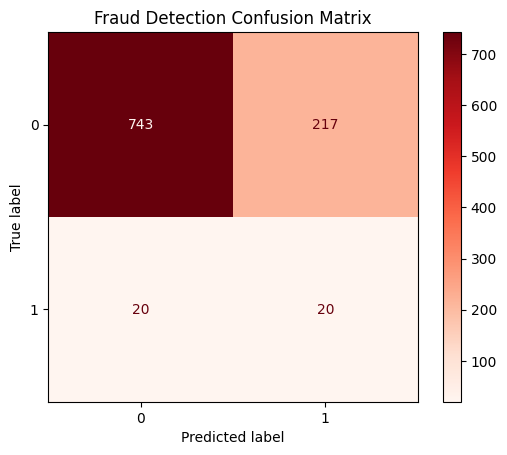

In [ ]:
from sklearn.metrics import ConfusionMatrixDisplay
import matplotlib.pyplot as plt

ConfusionMatrixDisplay.from_estimator(
    pipeline,
    X_test,
    y_test,
    cmap='Reds'
)

plt.title("Fraud Detection Confusion Matrix")
plt.show()

## Model Explainability: Key Fraud Risk Drivers

This section identifies which features contribute most strongly to fraud prediction.

Feature importance helps support explainable fraud investigation by showing which behavioral, transaction, customer, and merchant attributes influence model decisions.

This is important because fraud analysts need to understand not only whether a transaction is risky, but also why it was flagged.

In [ ]:
from sklearn.inspection import permutation_importance
import pandas as pd
import matplotlib.pyplot as plt

result = permutation_importance(
    pipeline,
    X_test,
    y_test,
    n_repeats=10,
    random_state=42,
    scoring='roc_auc'
)

feature_importance = pd.DataFrame({
    'Feature': X_test.columns,
    'Importance': result.importances_mean
}).sort_values(by='Importance', ascending=False)

feature_importance.head(10)

,Feature,Importance
9,alert_generated,0.033682
3,new_device_flag,0.021268
13,channel_Wire,0.019013
12,channel_P2P,0.017339
18,txn_country_IN,0.016807
2,device_risk_score,0.015453
4,velocity_1h,0.009094
15,txn_country_CA,0.008544
6,geo_distance_km,0.007523
0,transaction_amount_usd,0.005747


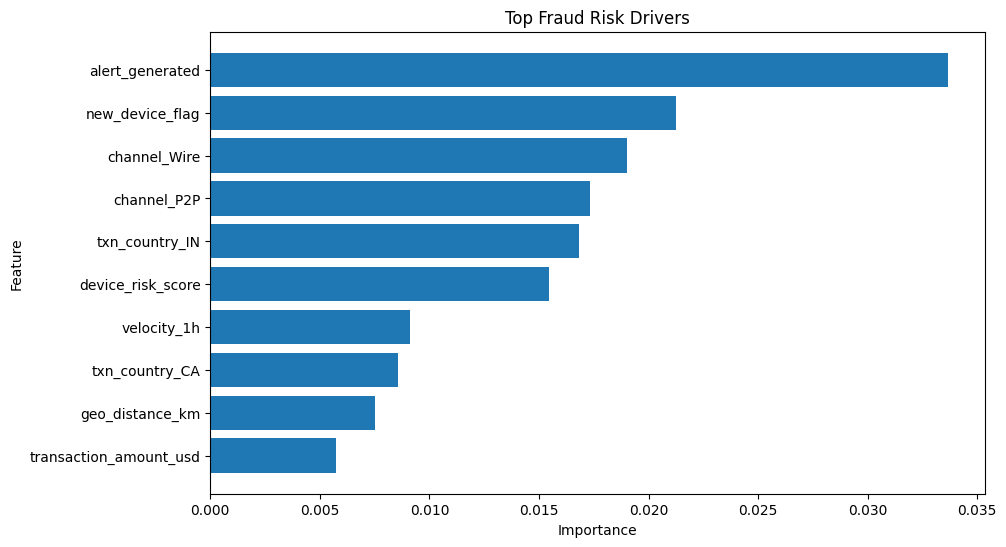

In [ ]:
plt.figure(figsize=(10, 6))

plt.barh(
    feature_importance['Feature'].head(10),
    feature_importance['Importance'].head(10)
)

plt.xlabel("Importance")
plt.ylabel("Feature")
plt.title("Top Fraud Risk Drivers")
plt.gca().invert_yaxis()
plt.show()

## Feature Importance Interpretation

The feature importance chart identifies the strongest drivers influencing the fraud prediction model.

These drivers help explain why certain transactions are more likely to be flagged as risky. This supports investigator trust because fraud analysts can connect model outputs to understandable business signals such as transaction behavior, customer risk, merchant activity, device usage, and timing patterns.

This explainability layer is important because fraud operations teams need transparent rationale when prioritizing alerts, not just a prediction score.

## Operational Interpretation of Model Performance

The confusion matrix highlights the tradeoff between fraud detection recall and operational false positives.

In fraud operations:
- False negatives represent missed fraudulent transactions,
- False positives increase investigator review workload,
- and threshold selection directly impacts queue efficiency.

The objective of the fraud prioritization framework is therefore not only to maximize prediction accuracy, but also to balance:
- fraud capture,
- operational scalability,
- investigator workload,
- and explainable alert prioritization.

## Model Evaluation and Interpretation

The Logistic Regression model achieved an ROC-AUC score of 0.64, indicating moderate ability to distinguish between fraudulent and legitimate transactions.

The model achieved a recall of 0.50 for the fraud class, meaning that 50% of fraudulent transactions were successfully identified.

Recall is prioritized in fraud detection because missing fraudulent activity is more costly than generating additional alerts.

However, precision for fraud detection was relatively low (0.08), indicating a high number of false positive alerts. This suggests that while the model captures fraud cases reasonably well, further optimization is required to reduce unnecessary fraud alerts.

Overall, the Logistic Regression model serves as a useful baseline model for fraud risk detection and demonstrates the complete machine learning workflow from preprocessing to evaluation.


In [ ]:
# Apply custom fraud probability threshold

# Lowering threshold increases fraud sensitivity
# This helps capture more fraudulent transactions

custom_threshold = 0.30

# Convert probabilities into fraud predictions
# If probability >= threshold → predict fraud (1)

y_pred_custom = (y_prob >= custom_threshold).astype(int)

In [ ]:
# Evaluate model performance using custom threshold

print("Custom Threshold:", custom_threshold)

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, y_pred_custom))

print("\nClassification Report:")
print(classification_report(y_test, y_pred_custom))

Custom Threshold: 0.3

Confusion Matrix:
[[197 763]
 [  8  32]]

Classification Report:
              precision    recall  f1-score   support

           0       0.96      0.21      0.34       960
           1       0.04      0.80      0.08        40

    accuracy                           0.23      1000
   macro avg       0.50      0.50      0.21      1000
weighted avg       0.92      0.23      0.33      1000



## Threshold Tuning Results

To improve fraud detection recall, the classification threshold was lowered from the default value of 0.50 to 0.30.

This adjustment increased fraud recall from 50% to 80%, meaning the model successfully detected a larger proportion of fraudulent transactions.

However, the lower threshold also significantly increased false positive alerts, reducing precision. This highlights the common tradeoff in fraud detection systems between maximizing fraud capture and minimizing operational alert volume.

Such threshold tuning reflects real-world banking practices, where thresholds are adjusted based on business risk tolerance and fraud investigation capacity.

## Business-Led Threshold Comparison

Fraud thresholds should be selected based on risk appetite and investigator capacity rather than model accuracy alone.

Three operational strategies are compared:

- Conservative: fewer alerts and lower investigation workload, but increased missed fraud exposure.
- Balanced: moderate fraud coverage with manageable investigation volumes.
- Aggressive: higher fraud capture but increased false positives and investigation workload.

The recommended operating threshold should balance fraud detection effectiveness, alert quality, and investigator scalability.

In [10]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix

# Threshold comparison for Logistic Regression probabilities

threshold_options = {
    "Conservative": 0.70,
    "Balanced": 0.50,
    "Aggressive": 0.30
}

threshold_results = []

for option, threshold in threshold_options.items():
    threshold_pred = (y_prob >= threshold).astype(int)
    
    tn, fp, fn, tp = confusion_matrix(y_test, threshold_pred).ravel()
    
    alerts_flagged = int(threshold_pred.sum())
    precision = precision_score(y_test, threshold_pred, zero_division=0)
    recall = recall_score(y_test, threshold_pred, zero_division=0)
    false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
    queue_hit_rate = tp / (tp + fp) if (tp + fp) > 0 else 0
    
    threshold_results.append({
        "Operating Option": option,
        "Threshold": threshold,
        "Alerts Flagged": alerts_flagged,
        "Precision": round(precision, 3),
        "Recall": round(recall, 3),
        "False Positives": int(fp),
        "False Negatives": int(fn),
        "False Positive Rate": round(false_positive_rate, 3),
        "Queue Hit Rate": round(queue_hit_rate, 3),
        "Estimated Investigator Cases": alerts_flagged
    })

threshold_comparison = pd.DataFrame(threshold_results)

threshold_comparison

,Operating Option,Threshold,Alerts Flagged,Precision,Recall,False Positives,False Negatives,False Positive Rate,Queue Hit Rate,Estimated Investigator Cases
0,Conservative,0.7,103,0.078,0.200,95,32,0.099,0.078,103
1,Balanced,0.5,262,0.073,0.475,243,21,0.253,0.073,262
2,Aggressive,0.3,518,0.050,0.650,492,14,0.512,0.050,518


### Threshold Recommendation

The balanced threshold (0.50) is recommended as the prototype operating point because it provides a practical compromise between fraud coverage and investigation workload.

The aggressive threshold captures more fraud but substantially increases investigation volume and false-positive exposure.

The conservative threshold reduces operational workload but allows a larger proportion of fraudulent activity to remain undetected.

For fraud operations teams, threshold selection is therefore a business decision rather than a modelling decision. The chosen threshold should reflect fraud-loss tolerance, investigation capacity, and operational service-level objectives.

In [ ]:
# Import XGBoost classifier
# XGBoost is an advanced gradient boosting algorithm widely used in fraud detection

from xgboost import XGBClassifier

In [ ]:
cat_cols = X.select_dtypes(include="object").columns

X = pd.get_dummies(X, columns=cat_cols, drop_first=True)

print(X.select_dtypes(include="object").columns.tolist())

[]


C:\Users\karthik\AppData\Local\Temp\ipykernel_28948\1828085603.py:1: Pandas4Warning: For backward compatibility, 'str' dtypes are included by select_dtypes when 'object' dtype is specified. This behavior is deprecated and will be removed in a future version. Explicitly pass 'str' to `include` to select them, or to `exclude` to remove them and silence this warning.
See https://pandas.pydata.org/docs/user_guide/migration-3-strings.html#string-migration-select-dtypes for details on how to write code that works with pandas 2 and 3.
  cat_cols = X.select_dtypes(include="object").columns


In [12]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

In [ ]:
# Create XGBoost fraud detection model

# Key configurations:
# - n_estimators controls number of boosting trees
# - max_depth controls tree complexity
# - learning_rate controls how quickly the model learns
# - scale_pos_weight helps handle fraud class imbalance
# - random_state ensures reproducible results
# - eval_metric avoids default warning messages

xgb_model = XGBClassifier(
    n_estimators=100,
    max_depth=4,
    learning_rate=0.1,
    scale_pos_weight=24,
    random_state=42,
    eval_metric="logloss"
)

In [ ]:
# Train XGBoost fraud detection model

xgb_model.fit(X_train, y_train)

,"objective objective: str | xgboost.sklearn._SklObjWProto | typing.Callable[[typing.Any, typing.Any], typing.Tuple[numpy.ndarray, numpy.ndarray]] | NoneSpecify the learning task and the corresponding learning objective or a customobjective function to be used.For custom objective, see :doc:`/tutorials/custom_metric_obj` and:ref:`custom-obj-metric` for more information, along with the end note forfunction signatures.",'binary:logistic'
,"base_score base_score: float | typing.List[float] | NoneThe initial prediction score of all instances, global bias.",None
,booster,None
,"callbacks callbacks: typing.List[xgboost.callback.TrainingCallback] | NoneList of callback functions that are applied at end of each iteration.It is possible to use predefined callbacks by using:ref:`Callback API `... note:: States in callback are not preserved during training, which means callback objects can not be reused for multiple training sessions without reinitialization or deepcopy... code-block:: python for params in parameters_grid: # be sure to (re)initialize the callbacks before each run callbacks = [xgb.callback.LearningRateScheduler(custom_rates)] reg = xgboost.XGBRegressor(**params, callbacks=callbacks) reg.fit(X, y)",None
,colsample_bylevel colsample_bylevel: float | NoneSubsample ratio of columns for each level.,None
,colsample_bynode colsample_bynode: float | NoneSubsample ratio of columns for each split.,None
,colsample_bytree colsample_bytree: float | NoneSubsample ratio of columns when constructing each tree.,None
,"device device: str | None.. versionadded:: 2.0.0Device ordinal, available options are `cpu`, `cuda`, and `gpu`.",None
,"early_stopping_rounds early_stopping_rounds: int | None.. versionadded:: 1.6.0- Activates early stopping. Validation metric needs to improve at least once in every **early_stopping_rounds** round(s) to continue training. Requires at least one item in **eval_set** in :py:meth:`fit`.- If early stopping occurs, the model will have two additional attributes: :py:attr:`best_score` and :py:attr:`best_iteration`. These are used by the :py:meth:`predict` and :py:meth:`apply` methods to determine the optimal number of trees during inference. If users want to access the full model (including trees built after early stopping), they can specify the `iteration_range` in these inference methods. In addition, other utilities like model plotting can also use the entire model.- If you prefer to discard the trees after `best_iteration`, consider using the callback function :py:class:`xgboost.callback.EarlyStopping`.- If there's more than one item in **eval_set**, the last entry will be used for early stopping. If there's more than one metric in **eval_metric**, the last metric will be used for early stopping.",None
,enable_categorical enable_categorical: boolSee the same parameter of :py:class:`DMatrix` for details.,False
,"eval_metric eval_metric: str | typing.List[str | typing.Callable] | typing.Callable | None.. versionadded:: 1.6.0Metric used for monitoring the training result and early stopping. It can be astring or list of strings as names of predefined metric in XGBoost (See:doc:`/parameter`), one of the metrics in :py:mod:`sklearn.metrics`, or anyother user defined metric that looks like `sklearn.metrics`.If custom objective is also provided, then custom metric should implement thecorresponding reverse link function.Unlike the `scoring` parameter commonly used in scikit-learn, when a callableobject is provided, it's assumed to be a cost function and by default XGBoostwill minimize the result during early stopping.For advanced usage on Early stopping like directly choosing to maximize insteadof minimize, see :py:obj:`xgboost.callback.EarlyStopping`.See :doc:`/tutorials/custom_metric_obj` and :ref:`custom-obj-metric` for moreinformation... code-block:: python from sklearn.datasets import load_diabetes from sklearn.metrics import mean_absolute_error X, y = load_diabetes(return_X_y=True) reg = xgb.XGBRegressor( tree_meth

In [785]:
# Generate fraud predictions using XGBoost model

# Predict fraud labels on unseen test data

xgb_pred = xgb_model.predict(X_test)

# Predict fraud probabilities
# These probabilities are used for ROC-AUC evaluation

xgb_prob = xgb_model.predict_proba(X_test)[:, 1]

In [ ]:
import shap

explainer = shap.TreeExplainer(xgb_model)
shap_values = explainer.shap_values(X_test)

print("SHAP values generated successfully")

SHAP values generated successfully


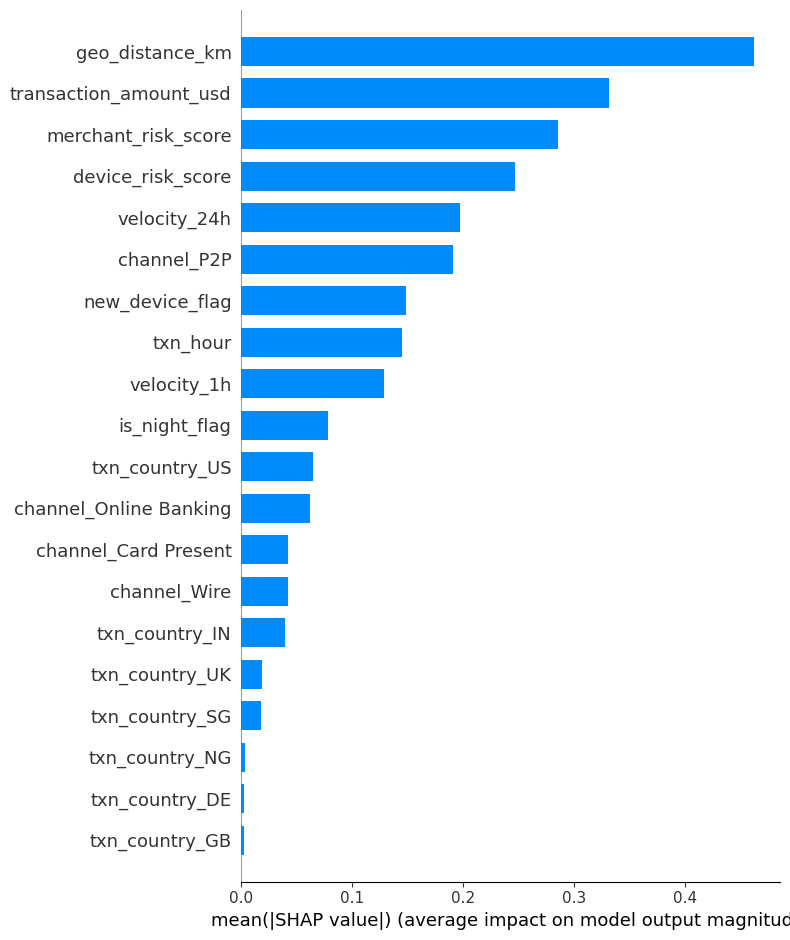

In [ ]:
shap.summary_plot(
    shap_values,
    X_test,
    plot_type="bar"
)

## SHAP Explainability Interpretation

SHAP analysis was used to identify the strongest drivers influencing the XGBoost fraud prioritization model.

The final SHAP results exclude `alert_generated` from the model features because it is treated as an operational alert filter rather than a predictive input. This reduces leakage risk and improves model governance.

The SHAP feature importance results show that fraud prioritization is primarily influenced by behavioral, transactional, merchant, device, velocity, and geographic risk indicators.

This strengthens investigator transparency by showing which factors contribute most to model-driven fraud risk scoring and supports explainable alert triage.

# Operational KPI Framework

This section translates model outputs into operational fraud investigation metrics.

The objective is to evaluate not only model performance, but also how effectively the model supports fraud operations by reducing missed fraud, improving alert quality, and helping investigators focus on higher-value alerts.

The operational KPIs include:

- Fraud Precision: measures alert quality
- Fraud Recall: measures fraud coverage
- False Positive Rate: measures wasted investigation effort
- Queue Hit Rate: measures investigator productivity
- Average Triage Score: measures queue severity

In [ ]:
# Evaluate XGBoost fraud detection performance

print("XGBoost ROC-AUC Score:", roc_auc_score(y_test, xgb_prob))

print("\nConfusion Matrix:")
print(confusion_matrix(y_test, xgb_pred))

print("\nClassification Report:")
print(classification_report(y_test, xgb_pred))

XGBoost ROC-AUC Score: 0.56265625

Confusion Matrix:
[[873  87]
 [ 30  10]]

Classification Report:
              precision    recall  f1-score   support

           0       0.97      0.91      0.94       960
           1       0.10      0.25      0.15        40

    accuracy                           0.88      1000
   macro avg       0.53      0.58      0.54      1000
weighted avg       0.93      0.88      0.91      1000



In [ ]:
from sklearn.metrics import precision_score, recall_score, confusion_matrix
import pandas as pd
import numpy as np

# Operational threshold for fraud alert generation
# This threshold can be adjusted later based on investigator capacity and risk appetite
operational_threshold = 0.50

# Generate operational alerts from XGBoost fraud probabilities
alert_generated = (xgb_prob >= operational_threshold).astype(int)

# Confusion matrix components
tn, fp, fn, tp = confusion_matrix(y_test, alert_generated).ravel()

# Operational KPI calculations
fraud_precision = precision_score(y_test, alert_generated, zero_division=0)
fraud_recall = recall_score(y_test, alert_generated, zero_division=0)
false_positive_rate = fp / (fp + tn) if (fp + tn) > 0 else 0
queue_hit_rate = tp / (tp + fp) if (tp + fp) > 0 else 0
average_triage_score = xgb_prob[alert_generated == 1].mean() if alert_generated.sum() > 0 else 0
alert_volume = alert_generated.sum()
total_cases = len(alert_generated)

operational_kpis = pd.DataFrame({
    "KPI": [
        "Fraud Precision",
        "Fraud Recall",
        "False Positive Rate",
        "Queue Hit Rate",
        "Average Triage Score",
        "Alert Volume",
        "Total Test Cases"
    ],
    "Value": [
        fraud_precision,
        fraud_recall,
        false_positive_rate,
        queue_hit_rate,
        average_triage_score,
        alert_volume,
        total_cases
    ],
    "Business Meaning": [
        "Share of flagged alerts that were actually fraud",
        "Share of actual fraud cases captured by the alerting logic",
        "Share of non-fraud cases incorrectly flagged for investigation",
        "Investigator productivity based on confirmed fraud within the alert queue",
        "Average model risk score among generated alerts",
        "Number of transactions sent to the investigation queue",
        "Total number of transactions evaluated in the test sample"
    ]
})

operational_kpis

,KPI,Value,Business Meaning
0,Fraud Precision,0.103093,Share of flagged alerts that were actually fraud
1,Fraud Recall,0.250000,Share of actual fraud cases captured by the al...
2,False Positive Rate,0.090625,Share of non-fraud cases incorrectly flagged f...
3,Queue Hit Rate,0.103093,Investigator productivity based on confirmed f...
4,Average Triage Score,0.638708,Average model risk score among generated alerts
5,Alert Volume,97.000000,Number of transactions sent to the investigati...
6,Total Test Cases,1000.000000,Total number of transactions evaluated in the ...


# Operational KPI Definitions

The following KPIs were implemented to evaluate the operational effectiveness of the fraud prioritization framework.

| KPI | Operational Definition | Business Purpose |
|---|---|---|
| Fraud Precision | Share of generated alerts that were confirmed as fraud | Measures alert quality and investigation efficiency |
| Fraud Recall | Share of actual fraud cases captured by the alerting workflow | Measures fraud detection coverage |
| False Positive Rate | Share of non-fraud transactions incorrectly escalated | Measures operational investigation waste |
| Queue Hit Rate | Share of investigated alerts that resulted in confirmed fraud | Measures investigator productivity |
| Average Triage Score | Average fraud probability score among escalated alerts | Measures overall queue severity |
| Alert Volume | Number of transactions escalated for review | Measures operational investigation workload |

These KPIs were designed to simulate operational fraud management tradeoffs rather than optimize for model accuracy alone.

## Threshold Strategy and Operational Tradeoffs

Fraud detection systems must balance fraud recall with operational investigation capacity.

Lower fraud thresholds increase fraud capture rates, but they also increase false positives and investigator review workload.

Higher thresholds reduce operational burden, but may increase the risk of missed fraudulent transactions.

The fraud prioritization framework in this project therefore focuses on balancing:
- fraud detection effectiveness,
- explainable prioritization,
- queue efficiency,
- and investigator scalability.

This operational tradeoff is critical in real-world fraud operations environments where analyst resources are limited and alert volumes are high.

## Governance, Explainability, and Operational Monitoring

Fraud detection systems require continuous monitoring, explainability, and governance controls to maintain operational effectiveness and investigator trust.

The fraud prioritization framework in this project is designed to support investigators rather than replace human judgment.

Several governance considerations are important in real-world fraud operations environments:

- Fraud behavior evolves over time and may introduce model drift
- Threshold strategies may require recalibration as alert volumes change
- False positives can increase operational investigation workload
- Explainability is required for investigator trust and operational transparency
- High-risk alerts should support clear escalation rationale
- Human analyst review remains critical for complex fraud investigations

The operational dashboard and explainability framework were therefore designed to improve:
- investigator efficiency,
- fraud triage transparency,
- and explainable operational decision-making.

# Operational Fraud Model Card

## Model Overview
This project uses an XGBoost classification model to support explainable fraud alert prioritization within a simulated banking transaction environment.

The model was designed to assist operational fraud investigators by identifying higher-risk transactions for review and escalation.

## Intended Use
The model is intended for:
- fraud-risk prioritization,
- operational alert triage,
- investigator workflow simulation,
- and explainable fraud analytics prototyping.

The model is not intended for live autonomous fraud decision-making or production banking deployment.

## Modeling Scope
- Modeling grain: transaction-level
- Target variable: fraud_label
- Operational alert logic: threshold-based alert generation
- Primary modeling approach: XGBoost classification

## Key Features Used
The fraud prioritization framework incorporates:
- transaction characteristics,
- behavioral indicators,
- customer-risk attributes,
- merchant information,
- and device familiarity patterns.

## Operational KPIs
The operational evaluation framework includes:
- Fraud Precision
- Fraud Recall
- False Positive Rate
- Queue Hit Rate
- Average Triage Score
- Alert Volume

These metrics were designed to evaluate operational fraud effectiveness rather than model accuracy alone.

## Explainability and Governance
The framework emphasizes explainable fraud prioritization using operational dashboards, feature importance analysis, and investigator-focused risk interpretation.

Human analyst review remains essential for complex fraud investigations and escalation decisions.

## Assumptions and Limitations
- The dataset is synthetic and simplified for educational simulation purposes.
- Thresholds were selected for operational demonstration rather than production calibration.
- Fraud behavior patterns may not fully represent evolving real-world fraud activity.
- Operational KPIs are simulated representations of fraud operations workflows.

## Monitoring Considerations
Real-world fraud systems require continuous:
- threshold recalibration,
- false-positive monitoring,
- drift detection,
- and investigator feedback review
to maintain operational effectiveness over time.

## Investigator Dashboard Integration

The fraud intelligence framework was operationalized through an interactive Power BI dashboard designed to support investigator workflows and fraud triage operations.

The dashboard environment includes:
- executive fraud monitoring,
- operational fraud analysis,
- behavioral customer intelligence,
- explainable fraud prioritization,
- and investigator-facing alert review workflows.

Key dashboard capabilities include:
- fraud risk segmentation,
- operational alert prioritization,
- behavioral fraud pattern analysis,
- merchant concentration analysis,
- transaction channel monitoring,
- and investigation queue management.

The dashboard integration layer improves:
- operational transparency,
- investigator efficiency,
- explainability of fraud alerts,
- and fraud investigation prioritization.

## Final Model Comparison

Two machine learning models were evaluated for fraud detection:

1. Logistic Regression
2. XGBoost Classifier

The Logistic Regression model achieved a higher ROC-AUC score and significantly better fraud recall, detecting a larger proportion of fraudulent transactions.

The XGBoost model reduced false positive alerts but detected fewer fraud cases overall.

This comparison demonstrates that more complex models do not always outperform simpler baseline models, particularly when working with smaller datasets and limited fraud samples.

For this dataset, Logistic Regression provided better fraud detection sensitivity, while XGBoost offered improved alert precision and operational efficiency.

The project highlights the importance of evaluating machine learning models based on business objectives rather than relying solely on model complexity.

## Tools and Technologies Used

- Python
- pandas
- scikit-learn
- XGBoost
- matplotlib
- Jupyter Notebook / VS Code

The analysis workflow was implemented entirely within Python using pandas-based data processing and machine learning libraries.

# Data Cleaning for Dashboards

This section checks for missing values, duplicates, and datatype inconsistencies before further analysis.

In [ ]:
print("Transactions Shape:", transactions.shape)

print("Customers Shape:", customers.shape)

print("Merchants Shape:", merchants.shape)

Transactions Shape: (5000, 17)
Customers Shape: (5000, 8)
Merchants Shape: (5000, 4)


In [ ]:
transactions.head()

,transaction_id,event_ts,customer_id,merchant_id,channel,transaction_amount_usd,txn_country,txn_hour,device_risk_score,new_device_flag,velocity_1h,velocity_24h,geo_distance_km,merchant_risk_score,is_night_flag,alert_generated,fraud_label
0,T9028450,2025-01-12 06:38:00,C100000,M100000,Card Present,70.46,US,4,0.747,1,1,2,3.0,0.474,1,0,0
1,T9050670,2025-01-20 04:18:00,C100001,M100001,P2P,36.12,DE,3,0.197,0,1,3,1488.6,0.218,1,1,0
2,T9015811,2025-03-16 21:19:00,C100002,M100002,Card Not Present,156.38,SG,10,0.393,0,3,6,136.2,0.632,0,0,0
3,T9014668,2025-02-24 19:35:00,C100003,M100003,Card Present,97.55,US,6,0.125,0,3,5,30.5,0.632,0,0,0
4,T9057899,2025-01-30 14:22:00,C100004,M100004,Online Banking,160.49,AE,12,0.138,0,1,3,3.1,0.097,0,0,0


In [ ]:
customers.head()

,customer_id,age,tenure_months,segment,home_country,digital_only,kyc_risk_band,synthetic_identity_score
0,C101782,32,1970-01-01,Affluent,US,0,Low,0.126
1,C103917,37,1970-01-01,Affluent,IN,0,Low,0.508
2,C100221,54,1970-01-01,Mass,UK,1,Low,0.702
3,C102135,39,1970-01-01,Affluent,IN,1,Medium,0.035
4,C105224,49,1970-01-01,Mass,US,1,Low,0.170


In [ ]:
merchants.head()

,merchant_id,merchant_category,merchant_risk_score,channel_default
0,M100000,Utilities,0.554,Card Not Present
1,M100001,Digital Wallet,0.162,P2P
2,M100002,Travel,0.449,Card Not Present
3,M100003,Electronics,0.315,Online Banking
4,M100004,Telecom,0.079,Online Banking


In [ ]:
transactions.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 17 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   transaction_id          5000 non-null   str    
 1   event_ts                5000 non-null   str    
 2   customer_id             5000 non-null   str    
 3   merchant_id             5000 non-null   str    
 4   channel                 5000 non-null   str    
 5   transaction_amount_usd  5000 non-null   float64
 6   txn_country             5000 non-null   str    
 7   txn_hour                5000 non-null   int64  
 8   device_risk_score       5000 non-null   float64
 9   new_device_flag         5000 non-null   int64  
 10  velocity_1h             5000 non-null   int64  
 11  velocity_24h            5000 non-null   int64  
 12  geo_distance_km         5000 non-null   float64
 13  merchant_risk_score     5000 non-null   float64
 14  is_night_flag           5000 non-null   int64  
 15

In [ ]:
customers.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 8 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   customer_id               5000 non-null   str    
 1   age                       5000 non-null   int64  
 2   tenure_months             5000 non-null   str    
 3   segment                   5000 non-null   str    
 4   home_country              5000 non-null   str    
 5   digital_only              5000 non-null   int64  
 6   kyc_risk_band             5000 non-null   str    
 7   synthetic_identity_score  5000 non-null   float64
dtypes: float64(1), int64(2), str(5)
memory usage: 312.6 KB


In [ ]:
merchants.info()

<class 'pandas.DataFrame'>
RangeIndex: 5000 entries, 0 to 4999
Data columns (total 4 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   merchant_id          5000 non-null   str    
 1   merchant_category    5000 non-null   str    
 2   merchant_risk_score  5000 non-null   float64
 3   channel_default      5000 non-null   str    
dtypes: float64(1), str(3)
memory usage: 156.4 KB


In [ ]:
transactions.isnull().sum()

transaction_id            0
event_ts                  0
customer_id               0
merchant_id               0
channel                   0
transaction_amount_usd    0
txn_country               0
txn_hour                  0
device_risk_score         0
new_device_flag           0
velocity_1h               0
velocity_24h              0
geo_distance_km           0
merchant_risk_score       0
is_night_flag             0
alert_generated           0
fraud_label               0
dtype: int64

In [ ]:
customers.isnull().sum()

customer_id                 0
age                         0
tenure_months               0
segment                     0
home_country                0
digital_only                0
kyc_risk_band               0
synthetic_identity_score    0
dtype: int64

In [ ]:
merchants.isnull().sum()

merchant_id            0
merchant_category      0
merchant_risk_score    0
channel_default        0
dtype: int64

In [ ]:
transactions.duplicated().sum()

np.int64(0)

In [ ]:
customers.duplicated().sum()

np.int64(0)

In [ ]:
merchants.duplicated().sum()

np.int64(0)

In [ ]:
# Converting the transaction timestamp

In [ ]:
transactions['event_ts'] = pd.to_datetime(transactions['event_ts'])

# Validating Dataset Relationships

This section validates whether transaction records successfully match customer and merchant records across datasets.

Relationship validation is important because:
- it ensures data consistency,
- supports reliable dataset merging,
- and confirms the integrity of multi-entity fraud analysis.

Successful relationship matching enables customer-level and merchant-level fraud intelligence generation.

In [ ]:
transactions['customer_id'].isin(customers['customer_id']).mean()

np.float64(0.8356)

# Customer Relationship Integrity Analysis

The relationship validation process identified that not all transaction customer IDs successfully matched records in the customer dataset.

Approximately 16% of transaction records contain customer IDs that are missing from the customer dataset.

This may indicate:
- incomplete onboarding records,
- data synchronization issues,
- unidentified customer activity,
- or potential operational inconsistencies.

This observation is important because incomplete entity relationships may impact fraud investigation accuracy and customer-level risk analysis.

In [ ]:
missing_customers = transactions[
    ~transactions['customer_id'].isin(customers['customer_id'])
]

missing_customers.head()

,transaction_id,event_ts,customer_id,merchant_id,channel,transaction_amount_usd,txn_country,txn_hour,device_risk_score,new_device_flag,velocity_1h,velocity_24h,geo_distance_km,merchant_risk_score,is_night_flag,alert_generated,fraud_label
3,T9014668,2025-02-24 19:35:00,C100003,M100003,Card Present,97.55,US,6,0.125,0,3,5,30.5,0.632,0,0,0
4,T9057899,2025-01-30 14:22:00,C100004,M100004,Online Banking,160.49,AE,12,0.138,0,1,3,3.1,0.097,0,0,0
5,T9033198,2025-03-16 07:26:00,C100005,M100005,Card Present,11.27,IN,5,0.215,0,1,2,53.7,0.378,1,0,0
9,T9053944,2025-03-11 02:30:00,C100009,M100009,P2P,298.57,IN,18,0.204,1,0,2,22.2,0.143,0,0,0
16,T9008668,2025-01-04 09:47:00,C100016,M100016,Card Present,140.39,US,20,0.171,0,1,4,19.3,0.120,0,0,0


# Measuring Missing Customer Relationships

This step calculates the number of transaction records associated with customer IDs that do not exist in the customer dataset.

Quantifying missing relationships helps evaluate the scale of data integrity issues and their potential operational impact.

In [ ]:
missing_customers.shape

(822, 17)

# Identifying Unique Missing Customer IDs

This step identifies the number of unique customer IDs missing from the customer dataset.

This helps determine whether the issue is caused by:
- a few repeatedly missing customers,
- or widespread customer data inconsistencies.

In [ ]:
missing_customers['customer_id'].nunique()

822

# Merchant Relationship Integrity Analysis

This section investigates whether all merchant IDs present in the transaction dataset successfully match records in the merchant dataset.

Missing merchant relationships may indicate:
- incomplete merchant onboarding,
- synchronization failures,
- unsupported merchant transactions,
- or operational data inconsistencies.

Understanding merchant relationship quality is important for reliable merchant-level fraud intelligence.

In [ ]:
missing_merchants = transactions[
    ~transactions['merchant_id'].isin(merchants['merchant_id'])
]

missing_merchants.head()

,transaction_id,event_ts,customer_id,merchant_id,channel,transaction_amount_usd,txn_country,txn_hour,device_risk_score,new_device_flag,velocity_1h,velocity_24h,geo_distance_km,merchant_risk_score,is_night_flag,alert_generated,fraud_label


# Measuring Missing Merchant Relationships

This step calculates the number of transaction records associated with merchant IDs missing from the merchant dataset.

Quantifying missing merchant relationships helps assess the reliability of merchant-level analytics and fraud ecosystem analysis.

In [ ]:
missing_merchants.shape

(0, 17)

# Identifying Unique Missing Merchant IDs

This step identifies the number of unique merchant IDs missing from the merchant dataset.

This helps determine whether merchant inconsistencies are concentrated among a few merchants or spread across multiple entities.

In [ ]:
missing_merchants['merchant_id'].nunique()

0

# Fraud Analysis for Missing Customer Relationships

This section compares fraud activity between:
- transactions linked to valid customer records,
- and transactions associated with missing customer IDs.

This analysis helps determine whether incomplete customer relationships are correlated with elevated fraud activity.

In [ ]:
transactions['customer_match'] = transactions['customer_id'].isin(customers['customer_id'])

transactions.groupby('customer_match')['fraud_label'].mean() * 100

customer_match
False    4.136253
True     3.997128
Name: fraud_label, dtype: float64

# Fraud Analysis for Missing Merchant Relationships

This section compares fraud activity between:
- transactions linked to valid merchant records,
- and transactions associated with missing merchant IDs.

This helps evaluate whether incomplete merchant relationships are associated with increased fraud exposure.

In [ ]:
transactions['merchant_match'] = transactions['merchant_id'].isin(merchants['merchant_id'])

transactions.groupby('merchant_match')['fraud_label'].mean() * 100

merchant_match
True    4.02
Name: fraud_label, dtype: float64

# Merging Customer Data

This section merges customer-level information into the transaction dataset using the customer_id key.

Customer enrichment enables:
- customer behavior analysis,
- customer risk profiling,
- demographic fraud analysis,
- and multi-entity fraud intelligence generation.

In [ ]:
merged_data = transactions.merge(
    customers,
    on='customer_id',
    how='left'
)

# Merging Merchant Data

This section merges merchant-level information into the transaction dataset using the merchant_id key.

Merchant enrichment enables:
- merchant ecosystem analysis,
- merchant risk profiling,
- and fraud concentration analysis across merchant entities.

In [ ]:
merged_data = merged_data.merge(
    merchants,
    on='merchant_id',
    how='left'
)

# Inspecting the Enriched Master Dataset

This section inspects the merged analytical dataset after combining:
- transaction data,
- customer data,
- and merchant data.

The resulting master dataset supports integrated fraud intelligence analysis across multiple entities.

In [ ]:
merged_data.head()

,transaction_id,event_ts,customer_id,merchant_id,channel,transaction_amount_usd,txn_country,txn_hour,device_risk_score,new_device_flag,...,age,tenure_months,segment,home_country,digital_only,kyc_risk_band,synthetic_identity_score,merchant_category,merchant_risk_score_y,channel_default
0,T9028450,2025-01-12 06:38:00,C100000,M100000,Card Present,70.46,US,4,0.747,1,...,32.0,1970-04-26,Affluent,US,1.0,Medium,0.084,Utilities,0.554,Card Not Present
1,T9050670,2025-01-20 04:18:00,C100001,M100001,P2P,36.12,DE,3,0.197,0,...,64.0,1970-07-02,Mass,IN,1.0,Low,0.279,Digital Wallet,0.162,P2P
2,T9015811,2025-03-16 21:19:00,C100002,M100002,Card Not Present,156.38,SG,10,0.393,0,...,49.0,1970-07-10,SME,IN,1.0,Low,0.269,Travel,0.449,Card Not Present
3,T9014668,2025-02-24 19:35:00,C100003,M100003,Card Present,97.55,US,6,0.125,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Electronics,0.315,Online Banking
4,T9057899,2025-01-30 14:22:00,C100004,M100004,Online Banking,160.49,AE,12,0.138,0,...,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Telecom,0.079,Online Banking


In [ ]:
merged_data.shape

(5000, 29)

# Evaluating Missing Values After Dataset Integration

This step identifies missing values introduced during dataset merging.

Post-merge missing values are important because they may indicate:
- incomplete customer relationships,
- onboarding gaps,
- missing merchant attributes,
- or integration inconsistencies.

Understanding post-merge data quality is critical before advanced fraud analysis.

In [ ]:
merged_data.isnull().sum()

transaction_id                0
event_ts                      0
customer_id                   0
merchant_id                   0
channel                       0
transaction_amount_usd        0
txn_country                   0
txn_hour                      0
device_risk_score             0
new_device_flag               0
velocity_1h                   0
velocity_24h                  0
geo_distance_km               0
merchant_risk_score_x         0
is_night_flag                 0
alert_generated               0
fraud_label                   0
customer_match                0
merchant_match                0
age                         822
tenure_months               822
segment                     822
home_country                822
digital_only                822
kyc_risk_band               822
synthetic_identity_score    822
merchant_category             0
merchant_risk_score_y         0
channel_default               0
dtype: int64

# Fraud Analysis by Customer Segment

This section analyzes fraud distribution across customer segments.

Customer segmentation analysis helps identify:
- high-risk customer groups,
- behavioral fraud concentration,
- and segment-level exposure patterns.

Segment-based fraud intelligence supports targeted monitoring and risk prioritization strategies.

In [ ]:
merged_data.groupby('segment')['fraud_label'].mean() * 100

segment
Affluent    4.295943
Mass        3.900826
SME         4.126984
Name: fraud_label, dtype: float64

# Fraud Analysis by KYC Risk Band

This section evaluates fraud rates across KYC (Know Your Customer) risk bands.

KYC risk analysis helps determine whether:
- customers already classified as high-risk,
- are also associated with elevated fraud activity.

This supports explainable fraud intelligence and operational risk assessment validation.

In [ ]:
merged_data.groupby('kyc_risk_band')['fraud_label'].mean() * 100

kyc_risk_band
High      3.636364
Low       4.008992
Medium    4.071247
Name: fraud_label, dtype: float64

# Fraud Analysis by Merchant Category

This section evaluates fraud exposure across different merchant categories.

Merchant category analysis helps identify:
- industries associated with elevated fraud activity,
- high-risk transaction ecosystems,
- and operational fraud concentration patterns.

In [ ]:
merged_data.groupby('merchant_category')['fraud_label'].mean().sort_values(ascending=False) * 100

merchant_category
Fuel              4.971319
Utilities         4.572565
Gaming            4.400607
Electronics       4.261796
Luxury            4.230118
Telecom           3.744493
Grocery           3.577236
Marketplace       3.389831
Digital Wallet    3.108808
Travel            2.839117
Name: fraud_label, dtype: float64

# Fraud Analysis by Transaction Channel

This section analyzes fraud distribution across transaction channels.

Channel-level fraud analysis helps identify:
- vulnerable transaction environments,
- digital fraud exposure,
- and operational channel risk concentration.

In [ ]:
merged_data.groupby('channel')['fraud_label'].mean() * 100

channel
Card Not Present    2.869440
Card Present        3.793329
Online Banking      3.201708
P2P                 6.534422
Wire                6.007067
Name: fraud_label, dtype: float64

# Fraud Analysis for Night-Time Transactions

This section compares fraud rates between:
- daytime transactions,
- and night-time transactions.

Time-based fraud analysis helps identify behavioral fraud patterns and unusual transaction timing activity.

In [ ]:
merged_data.groupby('is_night_flag')['fraud_label'].mean() * 100

is_night_flag
0    3.479749
1    5.287818
Name: fraud_label, dtype: float64

# Fraud Analysis for New Device Activity

This section evaluates fraud exposure associated with transactions performed using new devices.

New device activity is an important fraud signal because:
- fraudsters frequently use unfamiliar devices,
- compromised accounts may exhibit device changes,
- and unusual device behavior may indicate elevated transaction risk.

In [ ]:
merged_data.groupby('new_device_flag')['fraud_label'].mean() * 100

new_device_flag
0    3.636807
1    5.758583
Name: fraud_label, dtype: float64

# Key Fraud Intelligence Findings

The analysis identified several important fraud behavior patterns across customers, merchants, transaction channels, and behavioral signals.

## Key Observations

### Customer Segment Analysis
- Affluent customers demonstrated slightly higher fraud exposure compared to other customer segments.
- Fraud activity was relatively distributed across all customer groups, indicating fraud is not isolated to a single segment.

### KYC Risk Band Analysis
- Existing KYC risk classifications did not strongly differentiate fraud exposure.
- Fraud rates were relatively similar across Low, Medium, and High KYC categories, suggesting transactional behavior may be more predictive than static onboarding risk profiles.

### Merchant Category Analysis
- Fuel, Utilities, and Gaming merchants showed the highest fraud exposure.
- Travel and Digital Wallet merchants demonstrated comparatively lower fraud rates.

### Transaction Channel Analysis
- P2P and Wire transactions exhibited significantly elevated fraud rates compared to other channels.
- These channels may require enhanced monitoring and transaction review workflows.

### Behavioral Fraud Signals
- Night-time transactions showed materially higher fraud exposure.
- Transactions involving new devices demonstrated significantly elevated fraud rates.

These findings support the development of an explainable fraud prioritization framework focused on behavioral and transactional risk signals.

# Building Explainable Fraud Risk Intelligence Framework

This section develops an explainable fraud risk scoring framework using behavioral and transactional fraud indicators identified during exploratory analysis.

Unlike black-box fraud models, this framework provides transparent and interpretable risk prioritization logic.

The scoring model incorporates:
- device risk,
- merchant risk,
- transaction velocity,
- new device activity,
- night-time behavior,
- geographic anomalies,
- and high-risk transaction channels.

Higher scores indicate elevated fraud exposure and investigation priority.

In [ ]:
merged_data['risk_score_v2'] = (
    merged_data['device_risk_score'] * 0.25 +
    merged_data['merchant_risk_score_x'] * 0.15 +
    merged_data['velocity_1h'] * 6 +
    merged_data['velocity_24h'] * 0.5 +
    merged_data['new_device_flag'] * 18 +
    merged_data['is_night_flag'] * 12 +
    merged_data['geo_distance_km'] * 0.015 +
    np.where(
        merged_data['channel'].isin(['P2P', 'Wire']),
        15,
        0
    )
)

# Evaluating Risk Score Performance

This section compares average fraud intelligence scores between:
- fraudulent transactions,
- and non-fraudulent transactions.

A successful risk framework should assign materially higher scores to fraudulent activity.

In [ ]:
merged_data.groupby('fraud_label')['risk_score_v2'].mean()

fraud_label
0    22.469781
1    38.043224
Name: risk_score_v2, dtype: float64

# Creating Risk Categories

This section converts continuous fraud risk scores into operational risk categories.

Risk categorization supports:
- fraud alert prioritization,
- investigation workflows,
- and operational monitoring dashboards.

The categories are:
- Low Risk
- Medium Risk
- High Risk

In [ ]:
merged_data['risk_category_v2'] = pd.cut(
    merged_data['risk_score_v2'],
    bins=[0, 25, 50, 1000],
    labels=['Low Risk', 'Medium Risk', 'High Risk']
)

# Risk Category Distribution

This section evaluates the distribution of transactions across operational risk categories.

Understanding category distribution helps assess:
- investigation workload,
- alert concentration,
- and prioritization efficiency.

In [ ]:
merged_data['risk_category_v2'].value_counts()

risk_category_v2
Low Risk       3151
Medium Risk    1508
High Risk       341
Name: count, dtype: int64

# Fraud Rate by Risk Category

This section evaluates whether higher operational risk categories correspond to elevated fraud exposure.

An effective explainable risk intelligence framework should demonstrate:
- increasing fraud rates across higher risk categories,
- and meaningful separation between low-risk and high-risk transactions.

In [ ]:
merged_data.groupby('risk_category_v2')['fraud_label'].mean() * 100

risk_category_v2
Low Risk        2.411933
Medium Risk     5.570292
High Risk      12.023460
Name: fraud_label, dtype: float64

In [3]:
merged_data = transactions.merge(
    customers,
    on='customer_id',
    how='left'
)

merged_data = merged_data.merge(
    merchants,
    on='merchant_id',
    how='left'
)

merged_data.shape

(5000, 27)

## Operational Action Bands

The explainable risk categories are converted into operational action bands so that the fraud score leads to a clear investigator decision.

Each risk tier is assigned a recommended action and service-level priority:

- High Risk → immediate escalation
- Medium Risk → analyst review
- Low Risk → monitoring or sample audit

This connects the risk score to practical fraud operations and supports investigator workflow design.

In [5]:
# Recreate explainable risk score and risk category before assigning actions

merged_data["risk_score_v2"] = (
    merged_data["device_risk_score"] * 0.25 +
    merged_data["merchant_risk_score_x"] * 0.15 +
    merged_data["velocity_1h"] * 6 +
    merged_data["velocity_24h"] * 0.5 +
    merged_data["new_device_flag"] * 18 +
    merged_data["is_night_flag"] * 12 +
    merged_data["geo_distance_km"] * 0.015 +
    np.where(
        merged_data["channel"].isin(["P2P", "Wire"]),
        15,
        0
    )
)

merged_data["risk_category_v2"] = pd.cut(
    merged_data["risk_score_v2"],
    bins=[0, 25, 50, 1000],
    labels=["Low Risk", "Medium Risk", "High Risk"]
)

merged_data[["risk_score_v2", "risk_category_v2"]].head()

,risk_score_v2,risk_category_v2
0,37.30285,Medium Risk
1,56.91095,High Risk
2,23.23605,Low Risk
3,21.08355,Low Risk
4,7.59555,Low Risk


In [6]:
# Convert risk categories into operational action bands

def assign_recommended_action(risk_category):
    if risk_category == "High Risk":
        return "Immediate escalation"
    elif risk_category == "Medium Risk":
        return "Analyst review"
    else:
        return "Monitor / sample audit"

def assign_sla_priority(risk_category):
    if risk_category == "High Risk":
        return "Same day review"
    elif risk_category == "Medium Risk":
        return "Review within 24 hours"
    else:
        return "Weekly monitoring"

merged_data["recommended_action"] = merged_data["risk_category_v2"].apply(assign_recommended_action)
merged_data["sla_priority"] = merged_data["risk_category_v2"].apply(assign_sla_priority)

merged_data[[
    "transaction_id",
    "risk_score_v2",
    "risk_category_v2",
    "recommended_action",
    "sla_priority"
]].head(10)

,transaction_id,risk_score_v2,risk_category_v2,recommended_action,sla_priority
0,T9028450,37.30285,Medium Risk,Analyst review,Review within 24 hours
1,T9050670,56.91095,High Risk,Immediate escalation,Same day review
2,T9015811,23.23605,Low Risk,Monitor / sample audit,Weekly monitoring
3,T9014668,21.08355,Low Risk,Monitor / sample audit,Weekly monitoring
4,T9057899,7.59555,Low Risk,Monitor / sample audit,Weekly monitoring
5,T9033198,19.91595,Low Risk,Monitor / sample audit,Weekly monitoring
6,T9003425,19.94825,Low Risk,Monitor / sample audit,Weekly monitoring
7,T9038500,8.25825,Low Risk,Monitor / sample audit,Weekly monitoring
8,T9005360,86.22340,High Risk,Immediate escalation,Same day review
9,T9053944,34.40545,Medium Risk,Analyst review,Review within 24 hours


## Transaction-Level Investigator Reason Codes

Fraud investigators need plain-English explanations, not only model scores or raw feature names.

This section converts key fraud indicators into transaction-level reason codes that explain why an alert may require review.

Reason codes support analyst judgement, challenge, and governance. They should be interpreted as investigation signals, not automatic proof of fraud.

In [7]:
# Generate transaction-level reason codes for investigator review

def generate_reason_codes(row):
    reasons = []
    
    if row.get("new_device_flag", 0) == 1:
        reasons.append("New device activity")
        
    if row.get("is_night_flag", 0) == 1:
        reasons.append("Night-time transaction")
        
    if row.get("channel", "") in ["P2P", "Wire"]:
        reasons.append("High-risk transaction channel")
        
    if row.get("device_risk_score", 0) >= merged_data["device_risk_score"].quantile(0.75):
        reasons.append("Elevated device risk")
        
    if row.get("merchant_risk_score_x", 0) >= merged_data["merchant_risk_score_x"].quantile(0.75):
        reasons.append("Elevated merchant risk")
        
    if row.get("velocity_1h", 0) >= merged_data["velocity_1h"].quantile(0.75):
        reasons.append("High short-term transaction velocity")
        
    if row.get("geo_distance_km", 0) >= merged_data["geo_distance_km"].quantile(0.75):
        reasons.append("Geographic anomaly")
        
    if row.get("merchant_category", "") in ["Fuel", "Utilities", "Gaming"]:
        reasons.append("Higher-risk merchant category")
        
    if len(reasons) == 0:
        reasons.append("No major behavioural trigger")
        
    return reasons[:3]

merged_data["top_reason_codes"] = merged_data.apply(generate_reason_codes, axis=1)

merged_data["reason_code_1"] = merged_data["top_reason_codes"].apply(lambda x: x[0] if len(x) > 0 else "")
merged_data["reason_code_2"] = merged_data["top_reason_codes"].apply(lambda x: x[1] if len(x) > 1 else "")
merged_data["reason_code_3"] = merged_data["top_reason_codes"].apply(lambda x: x[2] if len(x) > 2 else "")
merged_data["reason_codes"] = merged_data["top_reason_codes"].apply(lambda x: " | ".join(x))

merged_data[[
    "transaction_id",
    "risk_category_v2",
    "risk_score_v2",
    "reason_code_1",
    "reason_code_2",
    "reason_code_3",
    "recommended_action",
    "sla_priority"
]].head(10)

,transaction_id,risk_category_v2,risk_score_v2,reason_code_1,reason_code_2,reason_code_3,recommended_action,sla_priority
0,T9028450,Medium Risk,37.30285,New device activity,Night-time transaction,Elevated device risk,Analyst review,Review within 24 hours
1,T9050670,High Risk,56.91095,Night-time transaction,High-risk transaction channel,Geographic anomaly,Immediate escalation,Same day review
2,T9015811,Low Risk,23.23605,Elevated merchant risk,High short-term transaction velocity,Geographic anomaly,Monitor / sample audit,Weekly monitoring
3,T9014668,Low Risk,21.08355,Elevated merchant risk,High short-term transaction velocity,,Monitor / sample audit,Weekly monitoring
4,T9057899,Low Risk,7.59555,No major behavioural trigger,,,Monitor / sample audit,Weekly monitoring
5,T9033198,Low Risk,19.91595,Night-time transaction,Elevated merchant risk,Geographic anomaly,Monitor / sample audit,Weekly monitoring
6,T9003425,Low Risk,19.94825,Night-time transaction,,,Monitor / sample audit,Weekly monitoring
7,T9038500,Low Risk,8.25825,Elevated device risk,Geographic anomaly,,Monitor / sample audit,Weekly monitoring
8,T9005360,High Risk,86.22340,Night-time transaction,High-risk transaction channel,Geographic anomaly,Immediate escalation,Same day review
9,T9053944,Medium Risk,34.40545,New device activity,High-risk transaction channel,,Analyst review,Review within 24 hours


## Investigator Alert Queue Simulation

The enriched fraud intelligence dataset can now be transformed into an investigator-facing alert queue.

Each alert includes:

- Risk score
- Risk category
- Recommended action
- Service-level priority
- Explainable reason codes

This simulates how fraud operations teams prioritise alerts, allocate investigation resources, and manage operational workloads.

In [8]:
# Create investigator-facing alert queue

alert_queue = merged_data[[
    "transaction_id",
    "customer_id",
    "fraud_label",
    "risk_score_v2",
    "risk_category_v2",
    "recommended_action",
    "sla_priority",
    "reason_codes"
]].copy()

# Prioritise highest-risk alerts first

alert_queue = alert_queue.sort_values(
    by="risk_score_v2",
    ascending=False
)

# Display top investigator queue

alert_queue.head(20)

,transaction_id,customer_id,fraud_label,risk_score_v2,risk_category_v2,recommended_action,sla_priority,reason_codes
84,T9012956,C100084,0,256.26170,High Risk,Immediate escalation,Same day review,Night-time transaction | Geographic anomaly | ...
4538,T9003803,C104538,1,226.10370,High Risk,Immediate escalation,Same day review,New device activity | Geographic anomaly
1223,T9051238,C101223,1,192.90600,High Risk,Immediate escalation,Same day review,Night-time transaction | High-risk transaction...
4827,T9038438,C104827,0,178.36305,High Risk,Immediate escalation,Same day review,Night-time transaction | Geographic anomaly
4112,T9059261,C104112,0,176.64995,High Risk,Immediate escalation,Same day review,Night-time transaction | High short-term trans...
1137,T9032801,C101137,0,169.01365,High Risk,Immediate escalation,Same day review,Night-time transaction | High-risk transaction...
662,T9015147,C100662,0,166.96860,High Risk,Immediate escalation,Same day review,Night-time transaction | High-risk transaction...
4180,T9046436,C104180,0,165.56565,High Risk,Immediate escalation,Same day review,High short-term transaction velocity | Geograp...
4822,T9060793,C104822,0,161.63275,High Risk,Immediate escalation,Same day review,High short-term transaction velocity | Geograp...
1982,T9011890,C101982,0,151.84980,High Risk,Immediate escalation,Same day review,Night-time transaction | High-risk transaction...


In [13]:
# Export enhanced fraud intelligence dataset

merged_data.to_csv(
    "../../B_Dataset/processed/fraud_intelligence_dataset_enhanced.csv",
    index=False
)

print("Enhanced fraud intelligence dataset exported successfully.")
print("Rows exported:", len(merged_data))
print("Columns exported:", len(merged_data.columns))

Enhanced fraud intelligence dataset exported successfully.
Rows exported: 5000
Columns exported: 36


In [11]:
merged_data.columns.tolist()

['transaction_id',
 'event_ts',
 'customer_id',
 'merchant_id',
 'channel',
 'transaction_amount_usd',
 'txn_country',
 'txn_hour',
 'device_risk_score',
 'new_device_flag',
 'velocity_1h',
 'velocity_24h',
 'geo_distance_km',
 'merchant_risk_score_x',
 'is_night_flag',
 'alert_generated',
 'fraud_label',
 'age',
 'tenure_months',
 'segment',
 'home_country',
 'digital_only',
 'kyc_risk_band',
 'synthetic_identity_score',
 'merchant_category',
 'merchant_risk_score_y',
 'channel_default',
 'risk_score_v2',
 'risk_category_v2',
 'recommended_action',
 'sla_priority',
 'top_reason_codes',
 'reason_code_1',
 'reason_code_2',
 'reason_code_3',
 'reason_codes']

In [12]:
merged_data[[
    "transaction_id",
    "risk_score_v2",
    "risk_category_v2",
    "recommended_action",
    "sla_priority",
    "reason_code_1",
    "reason_code_2",
    "reason_code_3",
    "reason_codes"
]].head()

,transaction_id,risk_score_v2,risk_category_v2,recommended_action,sla_priority,reason_code_1,reason_code_2,reason_code_3,reason_codes
0,T9028450,37.30285,Medium Risk,Analyst review,Review within 24 hours,New device activity,Night-time transaction,Elevated device risk,New device activity | Night-time transaction |...
1,T9050670,56.91095,High Risk,Immediate escalation,Same day review,Night-time transaction,High-risk transaction channel,Geographic anomaly,Night-time transaction | High-risk transaction...
2,T9015811,23.23605,Low Risk,Monitor / sample audit,Weekly monitoring,Elevated merchant risk,High short-term transaction velocity,Geographic anomaly,Elevated merchant risk | High short-term trans...
3,T9014668,21.08355,Low Risk,Monitor / sample audit,Weekly monitoring,Elevated merchant risk,High short-term transaction velocity,,Elevated merchant risk | High short-term trans...
4,T9057899,7.59555,Low Risk,Monitor / sample audit,Weekly monitoring,No major behavioural trigger,,,No major behavioural trigger


## Governance and Operational Interpretation

The enhanced fraud intelligence framework extends beyond fraud prediction by incorporating operational action bands, investigator reason codes, and alert queue prioritisation.

Risk scores are translated into practical fraud operations workflows through recommended actions and service-level priorities. Explainable reason codes provide transparency into the behavioural and risk indicators influencing alert prioritisation.

The framework is intended to support investigator decision-making rather than automate fraud outcomes. Final investigation decisions remain subject to analyst review, operational policy, and organisational risk appetite.

This approach improves explainability, governance, operational transparency, and fraud investigation scalability.

# Explainable Risk Framework Performance Evaluation

The explainable fraud intelligence framework demonstrated strong separation between fraudulent and non-fraudulent transactions.

## Key Results

### Average Risk Score Comparison
- Non-Fraud Transactions: ~22.47
- Fraud Transactions: ~38.04

Fraudulent transactions received significantly higher average risk scores, indicating effective behavioral risk prioritization.

### Risk Category Distribution
- Low Risk: 3151 transactions
- Medium Risk: 1508 transactions
- High Risk: 341 transactions

The framework successfully concentrated a smaller subset of transactions into higher-priority investigation categories.

### Fraud Rate by Risk Category
- Low Risk: ~2.41%
- Medium Risk: ~5.57%
- High Risk: ~12.02%

Fraud exposure increased materially across higher risk categories, demonstrating effective operational fraud separation.

These results indicate that the explainable framework successfully prioritizes elevated-risk transactions using transparent behavioral fraud indicators.

# Fraud Distribution Visualization

This visualization compares the number of fraudulent and non-fraudulent transactions within the dataset.

Understanding fraud distribution is important for:
- evaluating dataset imbalance,
- understanding operational fraud prevalence,
- and designing investigation prioritization strategies.

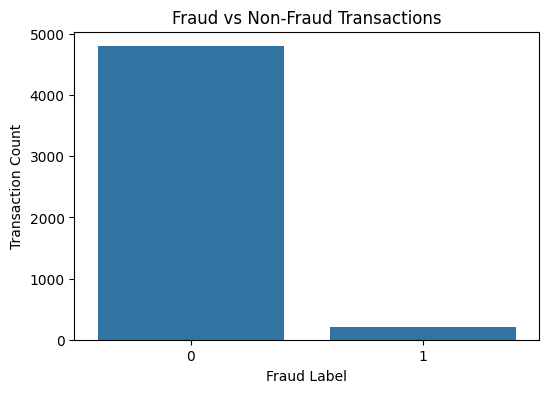

In [ ]:
plt.figure(figsize=(6,4))

sns.countplot(
    x='fraud_label',
    data=merged_data
)

plt.title('Fraud vs Non-Fraud Transactions')

plt.xlabel('Fraud Label')

plt.ylabel('Transaction Count')

plt.show()

## Fraud Class Imbalance Interpretation

The dataset demonstrates significant class imbalance, which is common in real-world fraud detection systems where fraudulent transactions represent a relatively small proportion of total transaction volume.

This creates several operational challenges:
- fraudulent activity may be overlooked,
- excessive false positives may increase investigator workload,
- and fraud detection thresholds must balance fraud recall with operational efficiency.

Because of this imbalance, fraud analytics systems require:
- threshold tuning,
- explainable prioritization logic,
- and investigator-focused triage strategies.

This project therefore focuses not only on fraud prediction accuracy, but also on operational fraud prioritization and explainable alert management.

# Fraud Rate by Transaction Channel

This visualization compares fraud exposure across transaction channels.

Channel-level fraud analysis helps identify:
- operationally vulnerable channels,
- elevated digital fraud exposure,
- and transaction environments requiring enhanced monitoring.

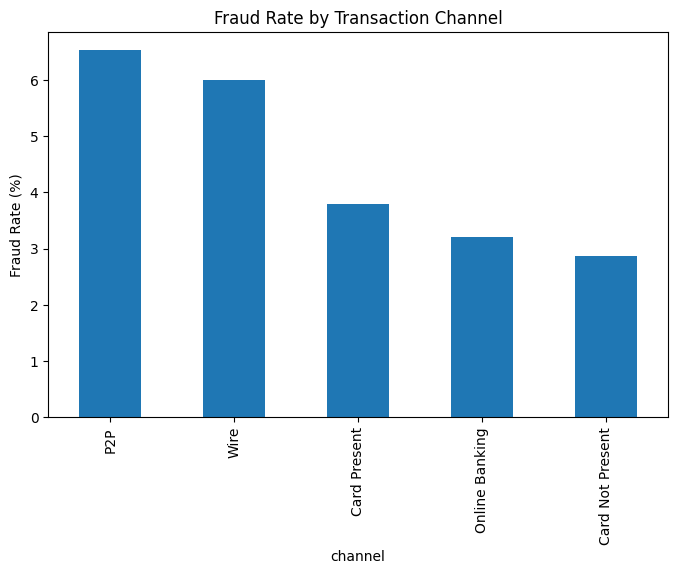

In [ ]:
channel_fraud = (
    merged_data
    .groupby('channel')['fraud_label']
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(8,5))

channel_fraud.plot(kind='bar')

plt.title('Fraud Rate by Transaction Channel')

plt.ylabel('Fraud Rate (%)')

plt.show()

# Fraud Rate by Merchant Category

This visualization highlights merchant categories associated with elevated fraud exposure.

Merchant ecosystem analysis helps identify:
- high-risk industries,
- fraud concentration environments,
- and operational monitoring priorities.

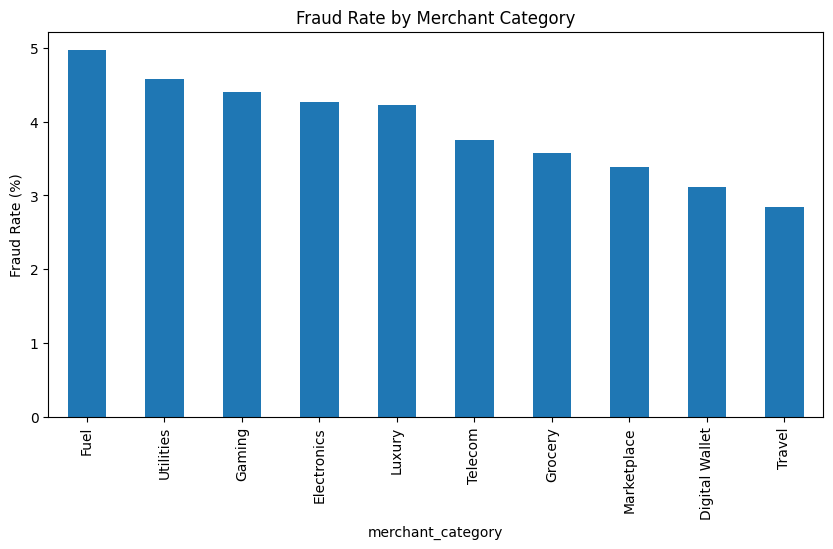

In [ ]:
merchant_fraud = (
    merged_data
    .groupby('merchant_category')['fraud_label']
    .mean()
    .sort_values(ascending=False) * 100
)

plt.figure(figsize=(10,5))

merchant_fraud.plot(kind='bar')

plt.title('Fraud Rate by Merchant Category')

plt.ylabel('Fraud Rate (%)')

plt.show()

# Fraud Rate by Risk Category

This visualization evaluates the effectiveness of the explainable fraud intelligence framework.

An effective operational fraud framework should demonstrate:
- increasing fraud concentration across higher risk categories,
- and meaningful separation between low-risk and high-risk transactions.

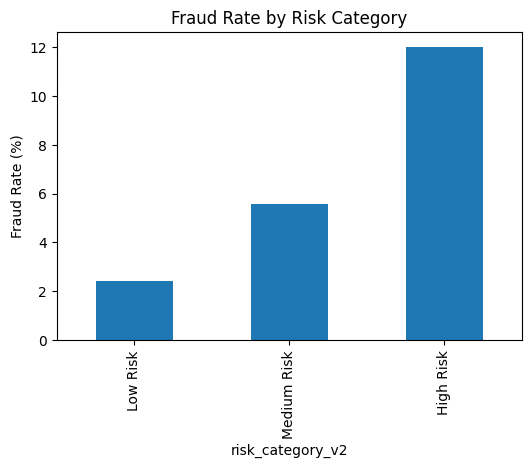

In [ ]:
risk_performance = (
    merged_data
    .groupby('risk_category_v2')['fraud_label']
    .mean() * 100
)

plt.figure(figsize=(6,4))

risk_performance.plot(kind='bar')

plt.title('Fraud Rate by Risk Category')

plt.ylabel('Fraud Rate (%)')

plt.show()

# Risk Score Distribution

This visualization shows the distribution of explainable fraud intelligence scores across all transactions.

Risk score distributions help evaluate:
- transaction concentration,
- score spread,
- and operational alert segmentation behavior.

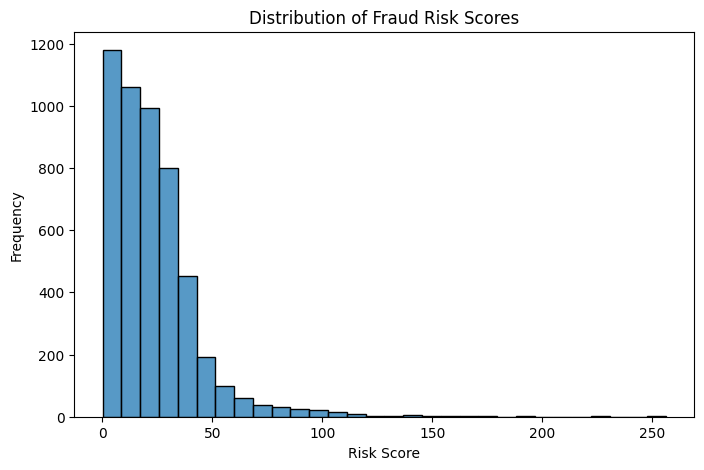

In [ ]:
plt.figure(figsize=(8,5))

sns.histplot(
    merged_data['risk_score_v2'],
    bins=30
)

plt.title('Distribution of Fraud Risk Scores')

plt.xlabel('Risk Score')

plt.ylabel('Frequency')

plt.show()

# Exporting Enriched Analytical Dataset

This step exports the enriched fraud intelligence dataset for dashboard development and visualization in Power BI.

The exported dataset includes:
- transaction intelligence,
- customer attributes,
- merchant information,
- fraud labels,
- and explainable risk scores.

This dataset serves as the foundation for executive fraud monitoring dashboards.

In [ ]:
merged_data.to_csv(
    '../../B_Dataset/processed/fraud_intelligence_dataset.csv',
    index=False
)

# Assumptions and Operational Limitations

This project was developed using a synthetic banking transaction environment designed to simulate fraud detection and operational alert-prioritization workflows.

Several assumptions and operational limitations should therefore be considered when interpreting the results.

## Key Assumptions
- Fraud probabilities generated by the XGBoost model are treated as operational fraud-risk indicators rather than production fraud decisions.
- Alert thresholds were selected to demonstrate operational tradeoffs between fraud recall, precision, and investigator workload.
- Investigation queues are simulated using threshold-based alert escalation logic.
- Behavioral fraud indicators and customer-risk features are simplified representations of realistic banking fraud environments.
- Operational KPIs are designed to simulate fraud operations management rather than live banking performance metrics.

## Operational Limitations
- The dataset is synthetic and does not represent live banking production systems.
- Fraud behavior patterns may not fully capture evolving real-world fraud tactics.
- Threshold calibration was not optimized using real financial loss exposure or investigation cost modeling.
- Service-level agreement monitoring and investigator staffing simulations were not fully implemented.
- Human investigator judgment remains essential for complex fraud investigation workflows.

## Prototype Positioning
The outputs of this project should therefore be interpreted as operational fraud analytics prototypes designed for educational and workflow simulation purposes rather than live production fraud decisions.

# Business Recommendations and Operational Actions

The operational KPI analysis indicates that the current fraud prioritization framework successfully identifies a portion of high-risk transactions while maintaining a manageable investigation queue size.

However, the KPI results also highlight the operational tradeoffs commonly observed in fraud operations environments.

## Key Operational Observations
- Fraud recall indicates that additional fraud cases may still bypass the current alerting threshold.
- Fraud precision and queue hit rate suggest that investigators may still experience operational overhead from false-positive alerts.
- Alert volume remains operationally manageable for investigator review workflows.
- Average triage scores indicate that the investigation queue is generally concentrated around higher-risk transactions.

## Recommended Operational Actions
- Continuously recalibrate fraud thresholds to balance fraud coverage against investigator workload.
- Prioritize high-risk alerts using explainable triage scoring and escalation logic.
- Monitor false-positive trends to reduce unnecessary investigation effort.
- Implement periodic governance reviews to evaluate model performance drift and operational effectiveness.
- Maintain human investigator review for complex fraud scenarios requiring contextual judgment.

## Leadership Recommendation
Leadership teams should focus on improving operational fraud prioritization efficiency rather than maximizing fraud detection volume alone. Effective fraud operations depend on balancing fraud recall, investigator scalability, explainability, and queue management effectiveness.

# Final Conclusion

This project developed an explainable fraud-alert prioritization framework designed to support operational fraud investigation workflows and investigator-facing decision intelligence.

The analysis combined:
- behavioral fraud analytics,
- operational risk segmentation,
- explainable fraud modeling,
- and interactive investigation dashboards.

Key fraud intelligence findings included:
- elevated fraud exposure across specific transaction channels,
- increased fraud risk associated with unfamiliar devices,
- operational concentration within high-risk merchant categories,
- and behavioral fraud indicators linked to customer segmentation and transaction timing.

The modeling and explainability framework demonstrated the importance of balancing:
- fraud detection effectiveness,
- investigator workload,
- operational scalability,
- and explainable alert prioritization.

To operationalize these insights, an integrated Power BI dashboard environment was developed to support:
- fraud monitoring,
- investigator triage workflows,
- alert prioritization,
- operational fraud analysis,
- and explainable fraud investigation.

Overall, the project demonstrates how fraud intelligence systems can combine predictive analytics, operational explainability, and investigator-focused dashboards to improve fraud operations efficiency and support risk-based decision-making.